# Proyecto Integrador M1 — Avance 1: Análisis Exploratorio de Datos (EDA)

**Autora:** Laura Garmendia
**Empresa (caso):** InsightReach — marketing digital para negocios locales
**Dataset:** `base_datos_restaurantes_USA_v2.csv` (clientes de restaurantes en 10 ciudades de EE.UU.)

---

### Objetivo de este notebook

Cargar y explorar la base de clientes, detectar problemas de calidad, filtrar una ciudad específica, limpiar y transformar los datos, y generar tablas básicas que describan a los clientes (género, preferencias alimenticias, consumo de licor, gasto, etc.). El resultado es un dataset limpio que se usará en el **Avance 2** (integración con la API de Yelp).

### Estructura de trabajo (una versión del DataFrame por etapa)

| DataFrame | Qué contiene | Para qué |
|---|---|---|
| `df_restaurantes_base` | El CSV tal cual se leyó | Referencia intacta: nunca se modifica, permite comparar el antes y el después |
| `df_restaurantes_limpia` | Ciudad filtrada + valores imposibles marcados como nulos | Separar el *diagnóstico* de errores de la *corrección* |
| `df_restaurantes_trans` | Nulos imputados + tipos de datos corregidos | Dataset final para tablas, gráficos y el Avance 2 |

En el **Avance 3** (secciones 11 a 15) la misma lógica se extiende con dos DataFrames más:

| DataFrame | Qué contiene | De dónde viene |
|---|---|---|
| `df_restaurantes_trans_todas` | Las 10 ciudades con la misma limpieza y transformación que `df_restaurantes_trans` | Se genera en la sección 11 aplicando `limpiar_base` a `df_restaurantes_base` |
| `df_clientes_enriquecido` | Clientes de Chicago + oferta de Yelp | Se crea en el notebook del Avance 2 con el mismo nombre y se lee aquí desde el CSV |

**Convención de nombres:** `df_` para DataFrames; `df_restaurantes_` + etapa (`base`, `limpia`, `trans`) + alcance (`_todas`, `_chicago`); constantes en MAYÚSCULAS, definidas una sola vez en la celda de parámetros; columnas y tablas de resultados en minúsculas con guion bajo, con el prefijo `porc_` para los porcentajes.

Trabajar con copias en lugar de modificar un único DataFrame hace el proceso **reproducible y auditable**: en cualquier momento se puede volver a una etapa anterior y verificar qué cambió.

## 1. Importación de librerías

- **pandas**: lectura del CSV y manipulación de tablas.
- **numpy**: operaciones numéricas y manejo de valores `NaN`.
- **matplotlib / seaborn**: visualizaciones.

También se configura cómo se muestran las tablas (todas las columnas, 2 decimales) para que las salidas sean legibles.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
pd.set_option("display.max_columns", None)       # mostrar todas las columnas
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (9, 5)

print("pandas:", pd.__version__, "| numpy:", np.__version__, "| seaborn:", sns.__version__)

pandas: 3.0.6 | numpy: 2.5.3 | seaborn: 0.13.2


### Parámetros del análisis

Todos los valores fijos del análisis se definen **una sola vez**, en esta celda. Si hay que cambiar algo (la ciudad, el rango de edades válidas, un color), se cambia aquí y el resto del notebook se adapta. La elección de la ciudad se justifica en la sección 5.1.

In [2]:
# Archivos
CARPETA_DATOS = "../ARCHIVOS"                                 # los datos están en la carpeta ARCHIVOS, al lado de Avances
RUTA_BASE = f"{CARPETA_DATOS}/base_datos_restaurantes_USA_v2.csv"   # base original de clientes
CIUDAD = "Chicago"                                         # ciudad analizada (criterio en la sección 5.1)
RUTA_LIMPIO = f"{CARPETA_DATOS}/clientes_{CIUDAD.lower()}_limpio.csv"            # salida del Avance 1 → entrada del Avance 2
RUTA_ENRIQUECIDO = f"{CARPETA_DATOS}/clientes_{CIUDAD.lower()}_enriquecido.csv"  # salida del Avance 2 → entrada del Avance 3

# Criterios de limpieza y agrupación
EDAD_MIN, EDAD_MAX = 18, 100
ORDEN_ESTRATO = ["Bajo", "Medio", "Alto", "Muy Alto"]
RANGOS_EDAD = [18, 25, 35, 45, 55, 65, 81]
ETIQUETAS_EDAD = ["18-24", "25-34", "35-44", "45-54", "55-64", "65-80"]
SIMBOLO_PRECIO = {1: "$", 2: "$$", 3: "$$$", 4: "$$$$"}   # nivel de precio numérico -> escala de Yelp (Avance 2)

# Colores: una sola paleta para todo el notebook
PALETA_ESTRATO = dict(zip(ORDEN_ESTRATO, ["#9ecae1", "#4292c6", "#2171b5", "#08306b"]))  # de claro a oscuro
COLOR_PRINCIPAL = "#08306b"    # dato principal
COLOR_BASE = "#b8c4d0"         # dato de referencia o "resto"
COLOR_DESTACADO = "#d9534f"    # la ciudad analizada en los rankings
COLOR_LINEA_REF = "#555555"    # líneas de promedio

### Funciones auxiliares

Se definen funciones reutilizables para no repetir código en cada tabla (modularización del código):

- **`tabla_frecuencias`:** cantidad y porcentaje de cada categoría de una columna.
- **`resumen_nulos`:** cantidad y porcentaje de nulos por columna.
- **`tabla_cruzada`:** porcentaje de cada categoría de una variable dentro de cada categoría de otra (cada fila suma 100). Es la tabla que se repite en casi todo el análisis.
- **`porcentaje_si`:** porcentaje de respuestas "Sí" en una columna Sí/No (licor, membresía, ocio).

In [3]:
def tabla_frecuencias(df, columna, orden=None):
    """Cantidad y porcentaje de cada categoría de `columna`."""
    conteo = df[columna].value_counts(dropna=False)
    if orden is not None:
        conteo = conteo.reindex(orden)
    tabla = pd.DataFrame({
        "cantidad": conteo,
        "porcentaje": (conteo / conteo.sum() * 100).round(2),
    })
    tabla.index.name = columna
    return tabla


def resumen_nulos(df):
    """Cantidad y porcentaje de nulos por columna (solo columnas con nulos)."""
    nulos = df.isnull().sum()
    tabla = pd.DataFrame({
        "nulos": nulos,
        "porcentaje": (nulos / len(df) * 100).round(2),
    })
    return tabla[tabla["nulos"] > 0].sort_values("nulos", ascending=False)


def tabla_cruzada(df, filas, columnas):
    """% de cada categoría de `columnas` dentro de cada categoría de `filas` (cada fila suma 100)."""
    return (pd.crosstab(df[filas], df[columnas], normalize="index") * 100).round(1)


def porcentaje_si(serie):
    """% de respuestas "Sí" en una columna Sí/No."""
    return (serie == "Sí").mean() * 100

## 2. Carga de datos

Se lee el archivo original en `df_restaurantes_base`. Este DataFrame **no se modifica en ningún momento**: es la "foto" original de los datos.

> El CSV está en la carpeta `ARCHIVOS` del proyecto, al mismo nivel que `Avances` (se ajusta con `CARPETA_DATOS` en la celda de parámetros). Los archivos que genera el análisis también se guardan allí.

In [4]:
df_restaurantes_base = pd.read_csv(RUTA_BASE)
print(f"Filas: {df_restaurantes_base.shape[0]:,} | Columnas: {df_restaurantes_base.shape[1]}")

Filas: 30,000 | Columnas: 17


## 3. Exploración inicial del dataset original

Antes de cambiar nada, se revisa el dataset desde varios ángulos. La idea es **entender primero y corregir después**: si se corrige sin diagnosticar, se corre el riesgo de tapar errores o de tomar decisiones sin fundamento.

### 3.1 Primeras filas, últimas filas y muestra aleatoria

`head()` y `tail()` muestran el inicio y el final del archivo (útil para detectar filas basura o totales al final). `sample()` muestra filas al azar, que suelen ser más representativas.

In [5]:
df_restaurantes_base.head()

,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
0,2550327378,Jackson,Gomez,31.00,Masculino,Miami,Alto,6,67.51,Sí,No,Vegetariano,Sí,(830)220-1926,NaN,Efectivo,6425
1,9446112038,Samantha,Soto,40.00,Femenino,Denver,Medio,2,44.92,Sí,Sí,Mariscos,No,881-476-1426,NaN,Efectivo,2374
2,3098363243,Terry,Adams,62.00,Femenino,Denver,Bajo,2,9.24,Sí,Sí,Vegetariano,No,NaN,diana74@example.net,Efectivo,1110
3,4013002847,James,Shannon,41.00,Masculino,Boston,Alto,5,30.74,Sí,Sí,Carnes,Sí,NaN,scottfrey@example.com,Tarjeta,6931
4,7372911048,Susan,Jones,49.00,Femenino,San Diego,Bajo,0,0.00,No,No,Carnes,No,243.248.8919,glassgary@example.org,Tarjeta,1350


In [6]:
df_restaurantes_base.tail()

,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
29995,4862097674,Robert,Cortez,20.00,Masculino,Houston,Alto,-3,30.82,Sí,Sí,Vegano,Sí,NaN,garciagregory@example.net,Tarjeta,5781
29996,9458262482,Michael,Holt,78.00,Masculino,Denver,Alto,5,45.04,No,No,Mariscos,No,NaN,jimmy77@example.org,Efectivo,7652
29997,3412365931,Rebecca,Henry,77.00,Femenino,San Diego,Muy Alto,7,93.55,No,Sí,Mariscos,Sí,NaN,NaN,Efectivo,12639
29998,8853079811,Tamara,Griffin,77.00,Femenino,Chicago,Bajo,1,6.18,Sí,No,Otro,No,(243)658-6543x11668,NaN,Tarjeta,1057
29999,4553644223,Tracey,Flynn,57.00,Femenino,Chicago,Bajo,1,6.96,No,Sí,Carnes,No,295.679.7926x321,NaN,Efectivo,1348


In [7]:
df_restaurantes_base.sample(5, random_state=42)

,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
2308,9736274495,Christine,Stewart,31.00,Femenino,Denver,Alto,6,71.68,Sí,Sí,Vegetariano,Sí,(652)905-3905x04580,NaN,Tarjeta,8023
22404,4337267248,Leroy,Stark,53.00,Masculino,Seattle,Alto,4,61.67,Sí,No,NaN,Sí,(239)863-1976,kgarcia@example.net,App,4599
23397,2051524719,Mercedes,Wheeler,63.00,Femenino,Denver,Medio,4,19.29,Sí,Sí,Vegetariano,No,001-329-562-5211x0091,richardherring@example.net,Tarjeta,3169
25058,8522844928,Alexa,Velez,56.00,Femenino,Chicago,Muy Alto,10,23.13,No,No,Vegetariano,Sí,NaN,NaN,Tarjeta,13822
2664,4585541728,Steven,Adkins,36.00,Masculino,Chicago,Medio,4,15.64,Sí,Sí,Vegetariano,No,NaN,jessicaadkins@example.com,Tarjeta,2344


### 3.2 Estructura y tipos de datos

`info()` muestra, para cada columna, la cantidad de valores no nulos y el tipo de dato. Sirve para detectar tipos incorrectos (por ejemplo, números guardados como texto o enteros guardados como decimales).

In [8]:
df_restaurantes_base.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_persona                 30000 non-null  int64  
 1   nombre                     30000 non-null  str    
 2   apellido                   30000 non-null  str    
 3   edad                       29899 non-null  float64
 4   genero                     30000 non-null  str    
 5   ciudad_residencia          30000 non-null  str    
 6   estrato_socioeconomico     30000 non-null  str    
 7   frecuencia_visita          30000 non-null  int64  
 8   promedio_gasto_comida      29855 non-null  float64
 9   ocio                       30000 non-null  str    
 10  consume_licor              30000 non-null  str    
 11  preferencias_alimenticias  28597 non-null  str    
 12  membresia_premium          30000 non-null  str    
 13  telefono_contacto          14834 non-null  str    
 14  c

### 3.3 Estadística descriptiva

`describe(include="all")` resume todas las columnas: en las numéricas muestra media, desvío, mínimo, cuartiles y máximo; en las de texto, la cantidad de valores únicos y el más frecuente. **Los mínimos y máximos son la primera alarma de valores imposibles.** Se traspone con `.T` para leer una columna por fila.

In [9]:
df_restaurantes_base.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_persona,30000.00,NaN,NaN,NaN,5504764563.82,2602799263.54,1000153386.00,3243617026.00,5515865060.00,7754425564.00,9999627377.00
nombre,30000,690,Michael,678,NaN,NaN,NaN,NaN,NaN,NaN,NaN
apellido,30000,1000,Smith,636,NaN,NaN,NaN,NaN,NaN,NaN,NaN
edad,29899.00,NaN,NaN,NaN,49.67,23.84,-5.00,33.00,49.00,65.00,300.00
genero,30000,2,Femenino,15044,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ciudad_residencia,30000,10,Chicago,5384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
estrato_socioeconomico,30000,4,Medio,9325,NaN,NaN,NaN,NaN,NaN,NaN,NaN
frecuencia_visita,30000.00,NaN,NaN,NaN,3.90,2.74,-3.00,2.00,4.00,5.00,10.00
promedio_gasto_comida,29855.00,NaN,NaN,NaN,32.60,26.40,0.00,13.29,25.51,44.40,149.97
ocio,30000,2,No,15094,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.4 Valores nulos

In [10]:
resumen_nulos(df_restaurantes_base)

,nulos,porcentaje
telefono_contacto,15166,50.55
correo_electronico,15072,50.24
preferencias_alimenticias,1403,4.68
promedio_gasto_comida,145,0.48
edad,101,0.34


### 3.5 Duplicados

Se revisan tres niveles:
1. **Filas completamente idénticas.**
2. **`id_persona` repetido** (el identificador debería ser único).
3. **Misma persona con distinto id**: coincidencia de nombre, apellido, edad y ciudad.

In [11]:
print("Filas duplicadas exactas:", df_restaurantes_base.duplicated().sum())
print("id_persona duplicados:   ", df_restaurantes_base["id_persona"].duplicated().sum())

columnas_persona = ["nombre", "apellido", "edad", "ciudad_residencia"]
posibles_duplicados = df_restaurantes_base[df_restaurantes_base.duplicated(columnas_persona, keep=False)]
print("Coincidencias nombre+apellido+edad+ciudad:", len(posibles_duplicados))
posibles_duplicados.sort_values(["nombre", "apellido"]).head(6)

Filas duplicadas exactas: 0
id_persona duplicados:    0
Coincidencias nombre+apellido+edad+ciudad: 20


,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
9577,3371470157,Chad,Williams,67.00,Masculino,Dallas,Alto,4,28.15,No,Sí,Mariscos,Sí,NaN,julieharmon@example.org,App,8950
15983,6664891973,Chad,Williams,67.00,Masculino,Dallas,Bajo,2,10.54,Sí,Sí,Carnes,No,(428)539-6046x75812,NaN,Efectivo,915
14581,1284690860,Christopher,Nguyen,22.00,Masculino,Denver,Alto,4,63.58,Sí,Sí,Mariscos,Sí,NaN,kayla85@example.com,App,4646
28808,1405958576,Christopher,Nguyen,22.00,Masculino,Denver,Medio,4,9.28,No,Sí,Pescado,No,001-728-831-6565x9670,wlarson@example.net,Tarjeta,2730
1915,8263688252,Elizabeth,Brown,46.00,Femenino,Denver,Bajo,2,NaN,No,No,Vegetariano,No,700.542.5276x959,denise10@example.com,Tarjeta,1487
17883,2627404374,Elizabeth,Brown,46.00,Femenino,Denver,Medio,2,37.74,Sí,No,Mariscos,No,NaN,NaN,Tarjeta,2494


Las coincidencias por nombre corresponden a **personas distintas** (homónimos): tienen distinto estrato, ingresos, preferencias y forma de pago. No se eliminan.

### 3.6 Valores únicos de las variables categóricas

Se revisa que cada categoría esté escrita de una sola forma (sin variantes como "masculino", "Masculino ", "M").

In [12]:
columnas_categoricas = [
    "genero", "ciudad_residencia", "estrato_socioeconomico", "ocio",
    "consume_licor", "preferencias_alimenticias", "membresia_premium",
    "tipo_de_pago_mas_usado",
]

for col in columnas_categoricas:
    valores = df_restaurantes_base[col].value_counts(dropna=False).to_dict()
    print(f"{col}: {valores}\n")

genero: {'Femenino': 15044, 'Masculino': 14956}

ciudad_residencia: {'Chicago': 5384, 'NYC': 4769, 'Miami': 3186, 'San Diego': 3075, 'Dallas': 2602, 'Boston': 2547, 'Denver': 2523, 'Houston': 2212, 'Seattle': 2191, 'Phoenix': 1511}

estrato_socioeconomico: {'Medio': 9325, 'Alto': 9038, 'Bajo': 6161, 'Muy Alto': 5476}

ocio: {'No': 15094, 'Sí': 14906}

consume_licor: {'Sí': 18483, 'No': 11517}

preferencias_alimenticias: {'Carnes': 7916, 'Vegetariano': 6580, 'Mariscos': 5212, 'Vegano': 3267, 'Pescado': 2983, 'Otro': 2639, nan: 1403}

membresia_premium: {'No': 17155, 'Sí': 12845}

tipo_de_pago_mas_usado: {'Efectivo': 11813, 'Tarjeta': 9954, 'App': 7678, 'Criptomoneda': 555}



In [13]:
# Espacios sobrantes al inicio o final de los textos
columnas_texto = columnas_categoricas + ["nombre", "apellido", "telefono_contacto", "correo_electronico"]
for col in columnas_texto:
    serie = df_restaurantes_base[col].dropna()
    con_espacios = (serie != serie.str.strip()).sum()
    print(f"{col:28s} -> valores con espacios sobrantes: {con_espacios}")

genero                       -> valores con espacios sobrantes: 0
ciudad_residencia            -> valores con espacios sobrantes: 0
estrato_socioeconomico       -> valores con espacios sobrantes: 0
ocio                         -> valores con espacios sobrantes: 0
consume_licor                -> valores con espacios sobrantes: 0
preferencias_alimenticias    -> valores con espacios sobrantes: 0
membresia_premium            -> valores con espacios sobrantes: 0
tipo_de_pago_mas_usado       -> valores con espacios sobrantes: 0
nombre                       -> valores con espacios sobrantes: 0
apellido                     -> valores con espacios sobrantes: 0
telefono_contacto            -> valores con espacios sobrantes: 0
correo_electronico           -> valores con espacios sobrantes: 0


### 3.7 Rangos de las variables numéricas

#### Edad

In [14]:
edad = df_restaurantes_base["edad"]
edad_invalida = (edad < EDAD_MIN) | (edad > EDAD_MAX)

print(f"Valores fuera del rango {EDAD_MIN}-{EDAD_MAX}:")
print(edad[edad_invalida].value_counts())
print("\nRango de las edades válidas:", edad[~edad_invalida].min(), "a", edad[~edad_invalida].max())
print("¿Hay edades con decimales?:", (edad.dropna() % 1 != 0).any())

Valores fuera del rango 18-100:
edad
300.00    110
-5.00      97
Name: count, dtype: int64

Rango de las edades válidas: 18.0 a 80.0
¿Hay edades con decimales?: False


Las edades erróneas **no son valores dispersos**: son siempre exactamente `-5` o `300`. Esto indica valores "centinela" (códigos de error de carga), no personas reales. Las edades válidas van de 18 a 80 años y ninguna tiene decimales: el tipo `float64` aparece solo porque la columna tiene nulos (en pandas, `NaN` es un float).

#### Frecuencia de visita

In [15]:
df_restaurantes_base["frecuencia_visita"].value_counts().sort_index()

frecuencia_visita
-3     1547
 0     1463
 1     1459
 2     3659
 3     3697
 4     5042
 5     5932
 6     3746
 7      878
 8      862
 9      839
 10     876
Name: count, dtype: int64

In [16]:
# ¿La frecuencia 0 coincide con gasto 0? (coherencia lógica)
frecuencia = df_restaurantes_base["frecuencia_visita"]
gasto = df_restaurantes_base["promedio_gasto_comida"]

print("Frecuencia = 0:", (frecuencia == 0).sum())
print("Frecuencia = 0 y gasto = 0:", ((frecuencia == 0) & (gasto == 0)).sum())
print("Frecuencia = -3 y gasto > 0:", ((frecuencia == -3) & (gasto > 0)).sum())

Frecuencia = 0: 1463
Frecuencia = 0 y gasto = 0: 1463
Frecuencia = -3 y gasto > 0: 1537


- `-3` visitas es imposible y aparece siempre con el mismo valor → otro valor centinela. Además, esas personas **sí registran gasto**, así que en realidad visitan restaurantes: el dato de frecuencia se perdió.
- `0` visitas es coherente: todas esas personas tienen gasto `0`. Es un dato válido (clientes que no van a restaurantes).

In [17]:
# La frecuencia de visita depende fuertemente del estrato
pd.crosstab(df_restaurantes_base["estrato_socioeconomico"], frecuencia)

frecuencia_visita,-3,0,1,2,3,4,5,6,7,8,9,10
estrato_socioeconomico,,,,,,,,,,,,
Alto,469,0,0,0,0,2827,2831,2911,0,0,0,0
Bajo,308,1463,1459,1458,1473,0,0,0,0,0,0,0
Medio,500,0,0,2201,2224,2215,2185,0,0,0,0,0
Muy Alto,270,0,0,0,0,0,916,835,878,862,839,876


#### Gasto promedio en comida y outliers (IQR)

El método IQR marca como atípico todo valor fuera de `[Q1 − 1.5·IQR , Q3 + 1.5·IQR]`. Primero se aplica sobre toda la columna y luego **dentro de cada estrato**, porque el gasto depende mucho del nivel socioeconómico.

In [18]:
def limites_iqr(serie):
    """Límites inferior y superior del método IQR: [Q1 − 1,5·IQR ; Q3 + 1,5·IQR]."""
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr


inf, sup = limites_iqr(gasto)
print(f"IQR global -> límites [{inf:.2f}, {sup:.2f}] | outliers: {((gasto < inf) | (gasto > sup)).sum()}")

print("\nIQR por estrato:")
for estrato, gasto_estrato in gasto.groupby(df_restaurantes_base["estrato_socioeconomico"]):
    inf, sup = limites_iqr(gasto_estrato.dropna())
    outliers = ((gasto_estrato < inf) | (gasto_estrato > sup)).sum()
    print(f"  {estrato:9s} -> límites [{inf:7.2f}, {sup:7.2f}] | outliers: {outliers}")

IQR global -> límites [-33.38, 91.06] | outliers: 1370

IQR por estrato:
  Alto      -> límites [ -22.87,   98.17] | outliers: 0
  Bajo      -> límites [  -6.71,   25.37] | outliers: 0
  Medio     -> límites [ -10.04,   57.72] | outliers: 0
  Muy Alto  -> límites [ -48.65,  175.13] | outliers: 0


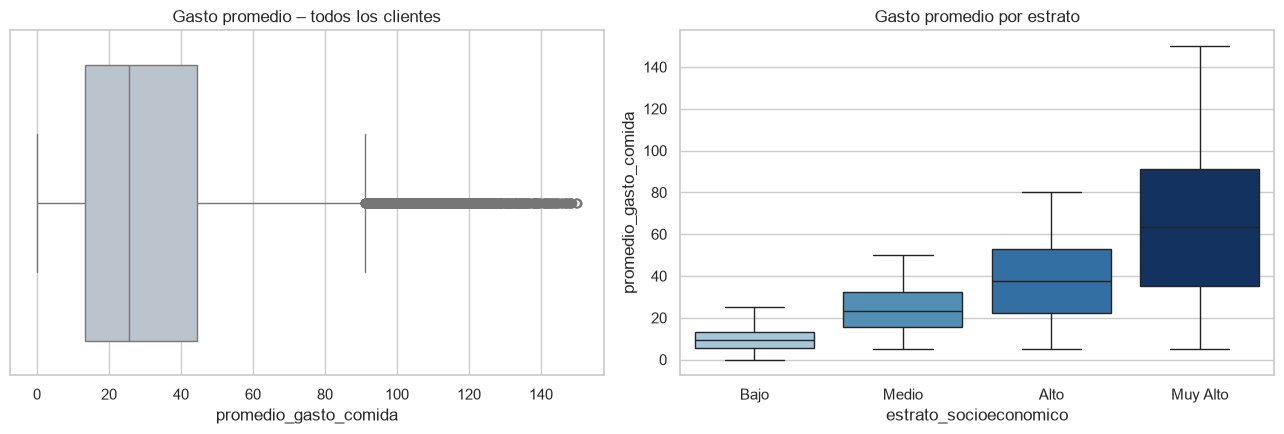

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(x=gasto, ax=axes[0], color=COLOR_BASE)
axes[0].set_title("Gasto promedio – todos los clientes")

sns.boxplot(data=df_restaurantes_base, x="estrato_socioeconomico", y="promedio_gasto_comida",
            hue="estrato_socioeconomico", order=ORDEN_ESTRATO, palette=PALETA_ESTRATO, legend=False, ax=axes[1])
axes[1].set_title("Gasto promedio por estrato")

plt.tight_layout()
plt.show()

**Hallazgo clave:** con el IQR global aparecen ~1.370 "outliers", pero al separar por estrato **no queda ninguno**. Los valores altos no son errores: son clientes de estrato *Muy Alto*, que gastan legítimamente más. Eliminarlos habría borrado justamente al segmento más valioso para marketing. Conclusión: el gasto **no requiere tratamiento de outliers**, solo imputar sus nulos.

#### Coherencia entre ingresos y estrato

In [20]:
df_restaurantes_base.groupby("estrato_socioeconomico")["ingresos_mensuales"].agg(["min", "max", "mean"]).reindex(ORDEN_ESTRATO)

,min,max,mean
estrato_socioeconomico,,,
Bajo,800,1599,1197.81
Medio,1600,3499,2544.76
Alto,3500,8999,6232.17
Muy Alto,9002,17999,13560.40


Los rangos de ingreso de cada estrato no se superponen y son crecientes: la variable es coherente y no presenta errores.

### 3.8 Distribución de clientes por ciudad

In [21]:
tabla_frecuencias(df_restaurantes_base, "ciudad_residencia")

,cantidad,porcentaje
ciudad_residencia,,
Chicago,5384,17.95
NYC,4769,15.90
Miami,3186,10.62
San Diego,3075,10.25
Dallas,2602,8.67
Boston,2547,8.49
Denver,2523,8.41
Houston,2212,7.37
Seattle,2191,7.30


## 4. Diagnóstico y decisiones

### Problemas detectados en `df_restaurantes_base` (30.000 filas, 17 columnas)

| Columna | Problema detectado | Decisión |
|---|---|---|
| `edad` | 101 nulos; 97 valores `-5` y 110 valores `300` (imposibles, valores centinela). Tipo `float64` aunque todas son enteras | Marcar `-5` y `300` como nulos → imputar con la **mediana por género** (dentro de la ciudad) → convertir a entero |
| `frecuencia_visita` | 1.547 valores `-3` (imposible). Esas personas sí registran gasto | Marcar como nulo → imputar con la **mediana por estrato** (la frecuencia depende del estrato) |
| `promedio_gasto_comida` | 145 nulos. IQR global marca ~1.370 outliers, pero por estrato hay 0 | No eliminar outliers (son clientes de estrato alto). Si frecuencia = 0 → gasto 0; si no, **mediana por estrato** |
| `preferencias_alimenticias` | 1.403 nulos (4,7 %) | Completar con la categoría **"No informado"** (ver justificación en 6.4) |
| `telefono_contacto` | 15.166 nulos (≈50 %); formatos muy variados | Completar con **"Dato no cargado"**. No se usa para el análisis |
| `correo_electronico` | 15.072 nulos (≈50 %); 454 correos repetidos entre personas distintas | Completar con **"Dato no cargado"**. Se deja constancia de los repetidos |
| `id_persona` | Tipo `int64`, pero es un identificador (no se hacen cuentas con él) | Convertir a **texto** (`str`) |
| Categóricas | Sin variantes de escritura ni espacios sobrantes | Convertir a tipo `category` (el estrato, ordenado) |
| Duplicados | 0 filas idénticas, 0 ids repetidos; 10 pares de homónimos (20 registros) que son personas distintas | No se elimina ningún registro |
| `ingresos_mensuales` | Sin problemas; coherente con el estrato | Sin cambios |

### Criterio general
- **No se eliminan filas con errores**: los problemas están en columnas puntuales y el resto de la fila tiene información valiosa. Borrar filas reduciría la muestra y podría sesgarla.
- **Imputación por grupos y con mediana**: la mediana no se ve afectada por valores extremos, y calcularla por grupo (género, estrato) respeta las diferencias reales entre segmentos en lugar de usar un único valor para todos.
- **Filtrar la ciudad antes de imputar**: así las medianas se calculan con los clientes de esa ciudad y no con los de todo el país.

## 5. Primera limpieza: `df_restaurantes_limpia`

En esta etapa **no se inventa ningún dato**: se filtra la ciudad y se convierten en nulos los valores imposibles, para que queden identificados de forma uniforme.

### 5.1 Filtrado por ciudad

**Ciudad elegida: Chicago.**
**Criterio:** es la ciudad con más clientes (5.384, ≈18 % de la base). Una muestra más grande da estadísticas más estables y permite segmentar (por estrato, género, preferencias) sin que los grupos queden demasiado chicos. Además, Chicago tiene una oferta gastronómica amplia en Yelp, lo que favorece la integración del Avance 2.

> Para analizar otra ciudad alcanza con cambiar la variable `CIUDAD` en la celda de parámetros: todo el resto del notebook se adapta solo.

In [22]:
df_restaurantes_limpia = (
    df_restaurantes_base[df_restaurantes_base["ciudad_residencia"] == CIUDAD]
    .copy()
    .reset_index(drop=True)
)

print(f"Clientes en {CIUDAD}: {len(df_restaurantes_limpia):,} "
      f"({len(df_restaurantes_limpia) / len(df_restaurantes_base):.1%} de la base)")

Clientes en Chicago: 5,384 (17.9% de la base)


Se usa `.copy()` para que el nuevo DataFrame sea independiente: modificarlo no altera `df_restaurantes_base` (y se evita el aviso *SettingWithCopyWarning*).

### 5.2 Marcar valores imposibles como nulos

Se reemplazan por `NaN` las edades fuera de 18–100 y las frecuencias negativas. A partir de acá, **todo dato faltante o erróneo está representado de la misma forma** (`NaN`), lo que permite tratarlo en un solo paso.

In [23]:
edad_invalida = (df_restaurantes_limpia["edad"] < EDAD_MIN) | (df_restaurantes_limpia["edad"] > EDAD_MAX)
frecuencia_invalida = df_restaurantes_limpia["frecuencia_visita"] < 0

print("Edades inválidas marcadas como nulo:     ", edad_invalida.sum())
print("Frecuencias inválidas marcadas como nulo:", frecuencia_invalida.sum())

df_restaurantes_limpia.loc[edad_invalida, "edad"] = np.nan
df_restaurantes_limpia.loc[frecuencia_invalida, "frecuencia_visita"] = np.nan

Edades inválidas marcadas como nulo:      29
Frecuencias inválidas marcadas como nulo: 286


In [24]:
# Verificación: nulos del DataFrame ya filtrado y con errores marcados
resumen_nulos(df_restaurantes_limpia)

,nulos,porcentaje
telefono_contacto,2730,50.71
correo_electronico,2712,50.37
frecuencia_visita,286,5.31
preferencias_alimenticias,268,4.98
edad,52,0.97
promedio_gasto_comida,35,0.65


## 6. Transformación: `df_restaurantes_trans`

Sobre una nueva copia se completan los nulos y se corrigen los tipos de datos.

In [25]:
df_restaurantes_trans = df_restaurantes_limpia.copy()

### 6.1 Edad → mediana por género

Se usa la **mediana** en lugar de la media porque es robusta ante valores extremos y siempre da una edad "real" (un número entero o medio). Se calcula por **género** porque la ciudad ya está fijada por el filtro. `groupby(...).transform("median")` devuelve, para cada fila, la mediana de su propio grupo.

In [26]:
mediana_edad = df_restaurantes_trans.groupby("genero")["edad"].transform("median")
print(df_restaurantes_trans.groupby("genero")["edad"].median())

df_restaurantes_trans["edad"] = df_restaurantes_trans["edad"].fillna(mediana_edad).round()

genero
Femenino    48.00
Masculino   49.00
Name: edad, dtype: float64


### 6.2 Frecuencia de visita → mediana por estrato

En la exploración se vio que cada estrato tiene su propio rango de visitas (el estrato Bajo va de 0 a 3, el Muy Alto de 5 a 10). Imputar con la mediana general asignaría valores irreales; por eso se usa la mediana **de su estrato**.

In [27]:
mediana_frecuencia = df_restaurantes_trans.groupby("estrato_socioeconomico")["frecuencia_visita"].transform("median")
print(df_restaurantes_trans.groupby("estrato_socioeconomico")["frecuencia_visita"].median())

df_restaurantes_trans["frecuencia_visita"] = df_restaurantes_trans["frecuencia_visita"].fillna(mediana_frecuencia)

estrato_socioeconomico
Alto       5.00
Bajo       2.00
Medio      4.00
Muy Alto   7.00
Name: frecuencia_visita, dtype: float64


### 6.3 Gasto promedio en comida → regla lógica + mediana por estrato

1. Si la persona **no visita restaurantes** (frecuencia 0), su gasto es 0: no es una estimación, es una deducción lógica.
2. Para el resto, se usa la **mediana del estrato**, ya que el gasto depende fuertemente del nivel socioeconómico.

No se eliminan outliers: como se mostró en 3.7, dentro de cada estrato no hay valores atípicos.

In [28]:
# 1. Regla lógica: quien no visita restaurantes tiene gasto 0
gasto_nulo = df_restaurantes_trans["promedio_gasto_comida"].isna()
no_visita = df_restaurantes_trans["frecuencia_visita"] == 0
print("Gasto nulo con frecuencia 0 (se completa con 0):", (gasto_nulo & no_visita).sum())

df_restaurantes_trans.loc[gasto_nulo & no_visita, "promedio_gasto_comida"] = 0

# 2. El resto: mediana del estrato, calculada solo con quienes sí visitan
gasto_de_quienes_visitan = df_restaurantes_trans["promedio_gasto_comida"].where(~no_visita)
mediana_gasto = gasto_de_quienes_visitan.groupby(df_restaurantes_trans["estrato_socioeconomico"]).transform("median")
print(gasto_de_quienes_visitan.groupby(df_restaurantes_trans["estrato_socioeconomico"]).median())

df_restaurantes_trans["promedio_gasto_comida"] = df_restaurantes_trans["promedio_gasto_comida"].fillna(mediana_gasto)

Gasto nulo con frecuencia 0 (se completa con 0): 0
estrato_socioeconomico
Alto       32.95
Bajo        7.53
Medio      17.57
Muy Alto   53.11
Name: promedio_gasto_comida, dtype: float64


### 6.4 Preferencias alimenticias → categoría "No informado"

**¿Por qué no la moda?** La moda ("Carnes") le asignaría la misma preferencia a todos los clientes sin dato, inflando artificialmente esa categoría. En una variable de **preferencia personal** no hay forma de deducir el gusto de alguien, y para una campaña de marketing es peor enviar una promoción de carnes a alguien vegano que no enviarle nada específico. Con "No informado" el dato faltante queda visible y medible (≈5 %), y ese grupo puede tratarse como un segmento propio (por ejemplo, una encuesta para completar su perfil).

> Alternativa si se prefiere la moda:
> `df_restaurantes_trans["preferencias_alimenticias"] = df_restaurantes_trans["preferencias_alimenticias"].fillna(df_restaurantes_trans["preferencias_alimenticias"].mode()[0])`

In [29]:
df_restaurantes_trans["preferencias_alimenticias"] = df_restaurantes_trans["preferencias_alimenticias"].fillna("No informado")

### 6.5 Teléfono y correo → "Dato no cargado"

Son datos de contacto: no se pueden estimar y no intervienen en el análisis. Se completa con una leyenda explícita para que quede claro que el dato falta (y no que el cliente no tenga teléfono o correo).

In [30]:
for col in ["telefono_contacto", "correo_electronico"]:
    df_restaurantes_trans[col] = df_restaurantes_trans[col].fillna("Dato no cargado")

print("Correos repetidos entre distintas personas (se informa, no se modifica):",
      df_restaurantes_trans.loc[df_restaurantes_trans["correo_electronico"] != "Dato no cargado", "correo_electronico"].duplicated().sum())

Correos repetidos entre distintas personas (se informa, no se modifica): 14


### 6.6 Corrección de tipos de datos

- `id_persona` → **texto**: es un identificador, no una cantidad. Como texto no se puede sumar ni promediar por error, y en otras fuentes podría tener ceros a la izquierda.
- `edad` y `frecuencia_visita` → **entero**: son conteos/años completos. Después de imputar ya no tienen nulos, así que pueden ser `int`.
- Variables categóricas → **`category`**: ocupan menos memoria y dejan explícito que tienen un conjunto cerrado de valores. El estrato se define como **categoría ordenada** (Bajo < Medio < Alto < Muy Alto), así las tablas y gráficos respetan ese orden.

In [31]:
df_restaurantes_trans["id_persona"] = df_restaurantes_trans["id_persona"].astype(str)
df_restaurantes_trans["edad"] = df_restaurantes_trans["edad"].astype(int)
df_restaurantes_trans["frecuencia_visita"] = df_restaurantes_trans["frecuencia_visita"].astype(int)

# Las columnas categóricas son las mismas que se revisaron en la sección 3.6
for col in columnas_categoricas:
    df_restaurantes_trans[col] = df_restaurantes_trans[col].astype("category")

# El estrato, además, tiene un orden: Bajo < Medio < Alto < Muy Alto
df_restaurantes_trans["estrato_socioeconomico"] = pd.Categorical(
    df_restaurantes_trans["estrato_socioeconomico"], categories=ORDEN_ESTRATO, ordered=True
)

### 6.7 Verificación final

Se comprueba que no queden nulos, que los tipos sean los esperados y que los rangos sean válidos.

In [32]:
print("Nulos restantes:", df_restaurantes_trans.isnull().sum().sum())
print("Rango de edad:", df_restaurantes_trans["edad"].min(), "-", df_restaurantes_trans["edad"].max())
print("Rango de frecuencia:", df_restaurantes_trans["frecuencia_visita"].min(), "-", df_restaurantes_trans["frecuencia_visita"].max())
df_restaurantes_trans.info()

Nulos restantes: 0
Rango de edad: 18 - 80
Rango de frecuencia: 0 - 10
<class 'pandas.DataFrame'>
RangeIndex: 5384 entries, 0 to 5383
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   id_persona                 5384 non-null   str     
 1   nombre                     5384 non-null   str     
 2   apellido                   5384 non-null   str     
 3   edad                       5384 non-null   int64   
 4   genero                     5384 non-null   category
 5   ciudad_residencia          5384 non-null   category
 6   estrato_socioeconomico     5384 non-null   category
 7   frecuencia_visita          5384 non-null   int64   
 8   promedio_gasto_comida      5384 non-null   float64 
 9   ocio                       5384 non-null   category
 10  consume_licor              5384 non-null   category
 11  preferencias_alimenticias  5384 non-null   category
 12  membresia_premium          5384

In [33]:
df_restaurantes_trans.describe()

,edad,frecuencia_visita,promedio_gasto_comida,ingresos_mensuales
count,5384.00,5384.00,5384.00,5384.00
mean,48.73,4.21,25.53,5202.31
std,18.05,2.22,22.03,4514.16
min,18.00,0.00,0.00,801.00
25%,33.00,3.00,8.72,1818.50
50%,49.00,4.00,19.05,3244.50
75%,64.00,5.00,34.67,7439.25
max,80.00,10.00,104.92,17999.00


### 6.8 Comparación antes / después (Chicago)

In [34]:
columnas_imputadas = ["edad", "frecuencia_visita", "promedio_gasto_comida"]
df_restaurantes_base_chicago = df_restaurantes_base[df_restaurantes_base["ciudad_residencia"] == CIUDAD]

pd.DataFrame({
    "media_antes": df_restaurantes_base_chicago[columnas_imputadas].mean(),
    "media_despues": df_restaurantes_trans[columnas_imputadas].mean(),
})

,media_antes,media_despues
edad,49.18,48.73
frecuencia_visita,3.82,4.21
promedio_gasto_comida,25.53,25.53


La media de edad y de frecuencia cambia porque se eliminó el efecto de los valores imposibles (`300`, `-5`, `-3`), que distorsionaban los promedios. El gasto casi no cambia: la imputación no alteró su distribución.

## 7. Tablas de distribución de variables

Con el dataset limpio se construyen tablas de frecuencia (cantidad y %) y tablas cruzadas. Los porcentajes permiten comparar grupos de distinto tamaño.

### 7.1 Género

In [35]:
tabla_frecuencias(df_restaurantes_trans, "genero")

,cantidad,porcentaje
genero,,
Masculino,2716,50.45
Femenino,2668,49.55


### 7.2 Edad por rangos
La edad es continua; agruparla en rangos con `pd.cut` hace la tabla legible y útil para segmentar.

In [36]:
df_restaurantes_trans["rango_edad"] = pd.cut(
    df_restaurantes_trans["edad"], bins=RANGOS_EDAD, labels=ETIQUETAS_EDAD, right=False
)
tabla_frecuencias(df_restaurantes_trans, "rango_edad", orden=ETIQUETAS_EDAD)

,cantidad,porcentaje
rango_edad,,
18-24,597,11.09
25-34,891,16.55
35-44,833,15.47
45-54,889,16.51
55-64,837,15.55
65-80,1337,24.83


> Nota: el último rango (65-80) abarca 16 años y los demás 10, por eso concentra más clientes. Las edades están distribuidas de forma bastante pareja entre 18 y 80 años.

### 7.3 Estrato socioeconómico

In [37]:
tabla_frecuencias(df_restaurantes_trans, "estrato_socioeconomico", orden=ORDEN_ESTRATO)

,cantidad,porcentaje
estrato_socioeconomico,,
Bajo,1148,21.32
Medio,1798,33.40
Alto,1511,28.06
Muy Alto,927,17.22


### 7.4 Preferencias alimenticias

In [38]:
tabla_frecuencias(df_restaurantes_trans, "preferencias_alimenticias")

,cantidad,porcentaje
preferencias_alimenticias,,
Carnes,1589,29.51
Vegetariano,1123,20.86
Mariscos,696,12.93
Otro,591,10.98
Vegano,571,10.61
Pescado,546,10.14
No informado,268,4.98


### 7.5 Consumo de licor

In [39]:
tabla_frecuencias(df_restaurantes_trans, "consume_licor")

,cantidad,porcentaje
consume_licor,,
Sí,3375,62.69
No,2009,37.31


### 7.6 Ocio, membresía premium y medio de pago

In [40]:
tabla_frecuencias(df_restaurantes_trans, "ocio")

,cantidad,porcentaje
ocio,,
No,2712,50.37
Sí,2672,49.63


In [41]:
tabla_frecuencias(df_restaurantes_trans, "membresia_premium")

,cantidad,porcentaje
membresia_premium,,
No,3169,58.86
Sí,2215,41.14


In [42]:
tabla_frecuencias(df_restaurantes_trans, "tipo_de_pago_mas_usado")

,cantidad,porcentaje
tipo_de_pago_mas_usado,,
Efectivo,2120,39.38
Tarjeta,1790,33.25
App,1375,25.54
Criptomoneda,99,1.84


### 7.7 Frecuencia de visita (visitas por mes)

In [43]:
tabla_frecuencias(df_restaurantes_trans, "frecuencia_visita").sort_index()

,cantidad,porcentaje
frecuencia_visita,,
0,261,4.85
1,273,5.07
2,714,13.26
3,715,13.28
4,1017,18.89
5,1134,21.06
6,642,11.92
7,214,3.97
8,124,2.30


### 7.8 Tablas cruzadas

Las tablas cruzadas (`pd.crosstab`) muestran la relación entre dos variables. Con `normalize="index"` cada fila suma 100 %, lo que permite comparar grupos.

In [44]:
# Consumo de licor según género (% por fila)
tabla_cruzada(df_restaurantes_trans, "genero", "consume_licor")

consume_licor,No,Sí
genero,,
Femenino,35.50,64.50
Masculino,39.10,60.90


In [45]:
# Preferencias alimenticias según género (% por fila)
tabla_cruzada(df_restaurantes_trans, "genero", "preferencias_alimenticias")

preferencias_alimenticias,Carnes,Mariscos,No informado,Otro,Pescado,Vegano,Vegetariano
genero,,,,,,,
Femenino,29.90,12.60,5.30,10.50,9.80,10.70,21.20
Masculino,29.20,13.30,4.60,11.50,10.50,10.50,20.50


In [46]:
# Membresía premium según estrato (% por fila)
tabla_cruzada(df_restaurantes_trans, "estrato_socioeconomico", "membresia_premium")

membresia_premium,No,Sí
estrato_socioeconomico,,
Bajo,99.30,0.70
Medio,86.90,13.10
Alto,27.90,72.10
Muy Alto,4.70,95.30


In [47]:
# Indicadores de consumo por estrato
df_restaurantes_trans.groupby("estrato_socioeconomico", observed=True).agg(
    clientes=("id_persona", "count"),
    ingreso_medio=("ingresos_mensuales", "mean"),
    gasto_por_comida=("promedio_gasto_comida", "mean"),
    visitas_por_mes=("frecuencia_visita", "mean"),
)

,clientes,ingreso_medio,gasto_por_comida,visitas_por_mes
estrato_socioeconomico,,,,
Bajo,1148,1193.89,5.81,1.54
Medio,1798,2545.29,17.46,3.59
Alto,1511,6207.10,32.55,5.01
Muy Alto,927,13682.06,54.17,7.44


## 8. Visualizaciones iniciales

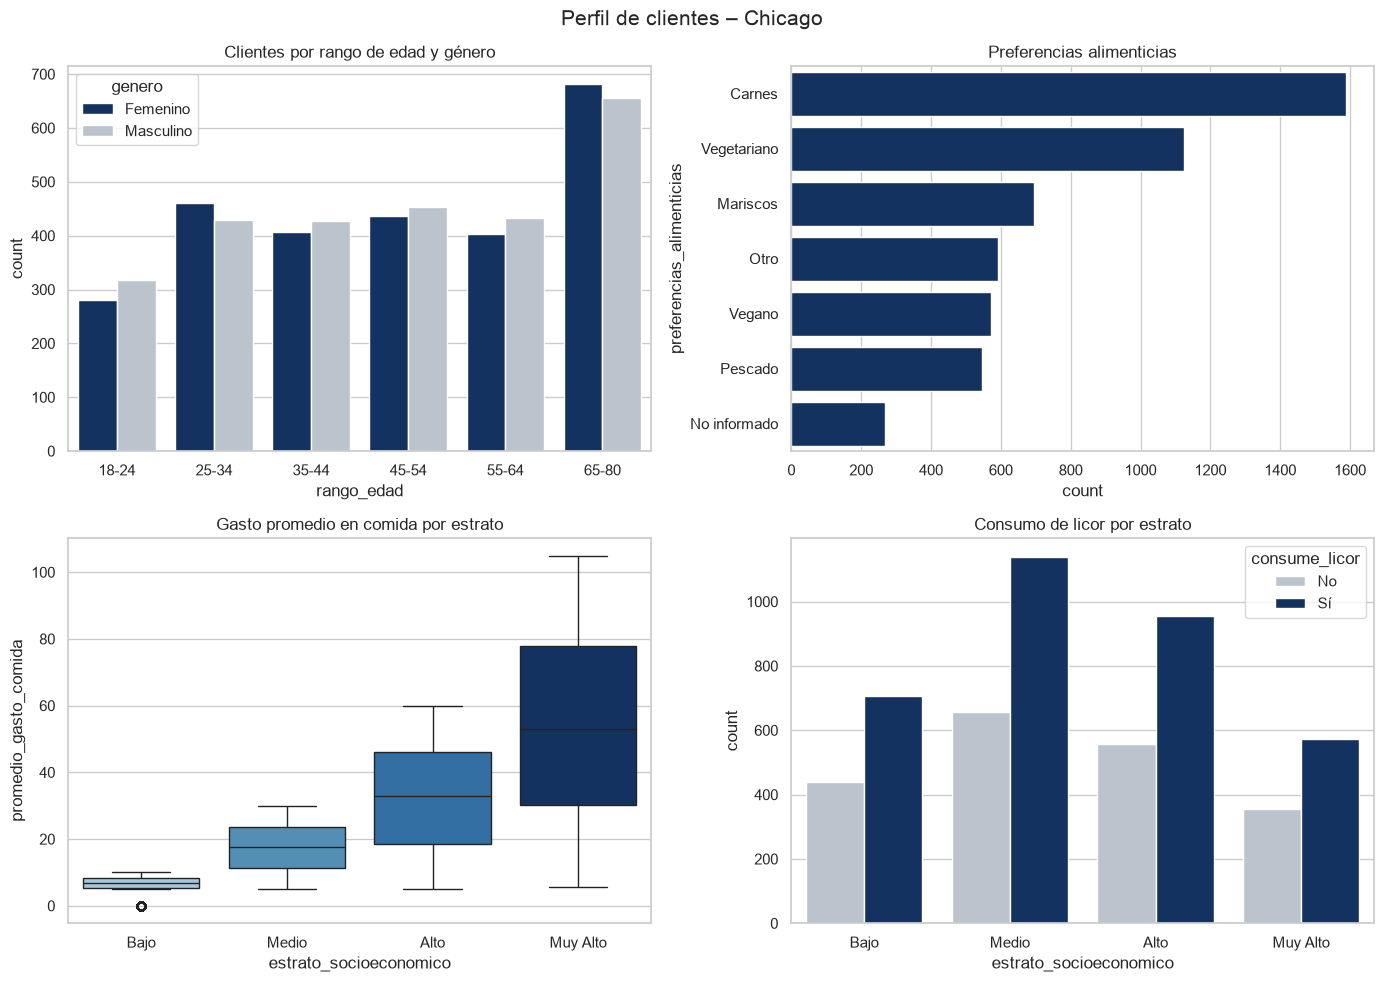

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df_restaurantes_trans, x="rango_edad", hue="genero",
              palette={"Femenino": COLOR_PRINCIPAL, "Masculino": COLOR_BASE}, ax=axes[0, 0])
axes[0, 0].set_title("Clientes por rango de edad y género")

orden_preferencias = df_restaurantes_trans["preferencias_alimenticias"].value_counts().index
sns.countplot(data=df_restaurantes_trans, y="preferencias_alimenticias", order=orden_preferencias,
              color=COLOR_PRINCIPAL, ax=axes[0, 1])
axes[0, 1].set_title("Preferencias alimenticias")

sns.boxplot(data=df_restaurantes_trans, x="estrato_socioeconomico", y="promedio_gasto_comida",
            hue="estrato_socioeconomico", palette=PALETA_ESTRATO, legend=False, dodge=False, ax=axes[1, 0])
axes[1, 0].set_title("Gasto promedio en comida por estrato")

sns.countplot(data=df_restaurantes_trans, x="estrato_socioeconomico", hue="consume_licor",
              palette={"Sí": COLOR_PRINCIPAL, "No": COLOR_BASE}, ax=axes[1, 1])
axes[1, 1].set_title("Consumo de licor por estrato")

plt.suptitle(f"Perfil de clientes – {CIUDAD}", fontsize=15)
plt.tight_layout()
plt.show()

## 9. Exportación del dataset limpio

Se guarda `df_restaurantes_trans` para usarlo como punto de partida en el **Avance 2 (API de Yelp)** sin repetir la limpieza.

In [49]:
df_restaurantes_trans.to_csv(RUTA_LIMPIO, index=False)
print("Archivo guardado:", RUTA_LIMPIO)

Archivo guardado: ../ARCHIVOS/clientes_chicago_limpio.csv


## 10. Conclusiones preliminares

**Sobre la calidad de los datos**
- La base original tenía errores sistemáticos (valores centinela `-5`, `300` y `-3`) más que errores aleatorios, lo que sugiere fallas en el proceso de carga. Se recomienda informarlo al área que genera los datos.
- Teléfono y correo faltan cada uno en cerca del 50 % de los registros. Combinando ambos, el **75 % de los clientes tiene al menos un canal de contacto** y el 25 % no tiene ninguno: esto **limita las campañas directas** y es un punto a mejorar en la captación.
- No había duplicados reales ni problemas de escritura en las categorías.
- El análisis de outliers mostró la importancia de **segmentar antes de juzgar un valor como atípico**: el gasto alto corresponde al estrato Muy Alto, no a errores.

**Sobre los clientes de Chicago** (5.384 clientes)
- **Género equilibrado** (≈50 % / 50 %) y edades repartidas de forma pareja entre 18 y 80 años: no hay un grupo etario dominante.
- **El estrato socioeconómico es la variable que más diferencia a los clientes.** Define el ingreso, el gasto por visita y la frecuencia, y casi determina la membresía premium: la tiene el 95 % del estrato Muy Alto y el 72 % del Alto, contra menos del 1 % del Bajo. El estrato Medio es el más numeroso (33 %) y tiene baja adhesión premium (13 %): es el segmento con más **potencial de conversión**.
- **El 63 % consume licor** (algo más en mujeres, 64,5 %, que en hombres, 60,9 %): hay espacio para promociones de bebidas.
- **Carnes (29,5 %) es la preferencia principal**, pero vegetarianos y veganos juntos suman ≈31 %: un nicho relevante para campañas de oferta *plant-based*. Las preferencias son prácticamente iguales entre géneros.
- **Medios de pago:** predomina el efectivo (39 %), seguido de tarjeta (33 %) y app (26 %).
- Uno de cada cuatro clientes no tiene ni teléfono ni correo cargado, lo que condiciona los canales de contacto de cualquier campaña.

**Próximos pasos (Avance 2)**
- Consultar la API de Yelp para obtener restaurantes de Chicago (categoría, calificación, reseñas, precio).
- Cruzar la oferta de Yelp con las preferencias y el estrato de los clientes para detectar oportunidades de segmentación.

---

# Avance 3: Análisis final y recomendaciones

### Objetivo

Analizar los datos integrados (clientes y oferta de Yelp) para **responder preguntas clave del negocio** con visualizaciones y análisis descriptivo, identificar patrones que orienten las decisiones de marketing y **proponer segmentaciones accionables** para las campañas de InsightReach.

### Cómo está organizado

| Parte | Alcance | Por qué |
|---|---|---|
| **11. Preparación** | Base limpia de las 10 ciudades + variable de gasto mensual | Varias preguntas comparan ciudades, así que hace falta limpiar todas con el mismo criterio que Chicago |
| **12. Preguntas de negocio** | Todas las ciudades | Responde las preguntas planteadas por la empresa |
| **13. Análisis integrado** | Chicago, clientes + Yelp | Combina el perfil de los clientes con la oferta real de la ciudad |
| **14. Segmentación y recomendaciones** | Chicago | Convierte los hallazgos en acciones concretas |

Cada pregunta sigue la misma estructura: **pregunta → código → gráfico → interpretación**.

## 11. Preparación de los datos para el análisis final

### 11.1 Limpieza de todas las ciudades con una función reutilizable

En el Avance 1 la limpieza se hizo paso a paso sobre Chicago. Ahora se necesita la base completa, así que los mismos pasos se reúnen en **una función** que se puede aplicar a cualquier conjunto de ciudades. Así el criterio es idéntico para todas y el código no se repite (modularización).

La única diferencia es que las medianas se calculan **por ciudad además de por género o estrato**, que es exactamente lo que se hizo con Chicago al filtrar primero la ciudad: cada ciudad se imputa con sus propios valores.

In [50]:
def limpiar_base(df, edad_min=EDAD_MIN, edad_max=EDAD_MAX):
    """Aplica los criterios de limpieza del Avance 1 a cualquier conjunto de ciudades.

    Las medianas se calculan dentro de cada ciudad, igual que al filtrar una ciudad antes de imputar.
    """
    d = df.copy()

    # 1. Valores imposibles -> nulo
    d.loc[(d["edad"] < edad_min) | (d["edad"] > edad_max), "edad"] = np.nan
    d.loc[d["frecuencia_visita"] < 0, "frecuencia_visita"] = np.nan

    # 2. Edad: mediana por ciudad y género
    mediana_edad = d.groupby(["ciudad_residencia", "genero"])["edad"].transform("median")
    d["edad"] = d["edad"].fillna(mediana_edad).round()

    # 3. Frecuencia: mediana por ciudad y estrato
    mediana_frecuencia = d.groupby(["ciudad_residencia", "estrato_socioeconomico"])["frecuencia_visita"].transform("median")
    d["frecuencia_visita"] = d["frecuencia_visita"].fillna(mediana_frecuencia)

    # 4. Gasto: 0 si no visita; si no, mediana por ciudad y estrato (de quienes sí visitan)
    gasto_nulo = d["promedio_gasto_comida"].isna()
    no_visita = d["frecuencia_visita"] == 0
    d.loc[gasto_nulo & no_visita, "promedio_gasto_comida"] = 0

    gasto_de_quienes_visitan = d["promedio_gasto_comida"].where(~no_visita)
    mediana_gasto = gasto_de_quienes_visitan.groupby(
        [d["ciudad_residencia"], d["estrato_socioeconomico"]]
    ).transform("median")
    d["promedio_gasto_comida"] = d["promedio_gasto_comida"].fillna(mediana_gasto)

    # 5. Categóricas y contacto
    d["preferencias_alimenticias"] = d["preferencias_alimenticias"].fillna("No informado")
    for col in ["telefono_contacto", "correo_electronico"]:
        d[col] = d[col].fillna("Dato no cargado")

    # 6. Tipos de datos
    d["id_persona"] = d["id_persona"].astype(str)
    d["edad"] = d["edad"].astype(int)
    d["frecuencia_visita"] = d["frecuencia_visita"].astype(int)
    d["estrato_socioeconomico"] = pd.Categorical(d["estrato_socioeconomico"], categories=ORDEN_ESTRATO, ordered=True)
    return d


df_restaurantes_trans_todas = limpiar_base(df_restaurantes_base)
print(f"Clientes: {len(df_restaurantes_trans_todas):,} | Nulos restantes: {df_restaurantes_trans_todas.isnull().sum().sum()}")

Clientes: 30,000 | Nulos restantes: 0


**Verificación:** si la función es correcta, al quedarse solo con Chicago tiene que dar **exactamente** el mismo resultado que la limpieza paso a paso del Avance 1 (`df_restaurantes_trans`). Se comprueba con `assert`: si algo no coincide, el notebook se detiene con un error.

In [51]:
df_verificacion_chicago = df_restaurantes_trans_todas[df_restaurantes_trans_todas["ciudad_residencia"] == CIUDAD].reset_index(drop=True)

for col in ["edad", "frecuencia_visita", "preferencias_alimenticias", "telefono_contacto"]:
    assert (df_verificacion_chicago[col].astype(str) == df_restaurantes_trans[col].astype(str)).all(), col
assert np.allclose(df_verificacion_chicago["promedio_gasto_comida"], df_restaurantes_trans["promedio_gasto_comida"])

print("La función reproduce exactamente la limpieza del Avance 1 para", CIUDAD)

La función reproduce exactamente la limpieza del Avance 1 para Chicago


### 11.2 Nueva variable: gasto mensual en restaurantes

La base informa el **gasto promedio por comida** y la **frecuencia de visita** (visitas por mes), pero varias preguntas se refieren al gasto *mensual*. Se construye multiplicando ambas:

$$\text{gasto mensual} = \text{gasto promedio por comida} \times \text{visitas por mes}$$

**Supuesto:** se considera un gasto por visita. Es una estimación: el dato real de gasto mensual no está en la base.

In [52]:
df_restaurantes_trans_todas["gasto_mensual"] = df_restaurantes_trans_todas["promedio_gasto_comida"] * df_restaurantes_trans_todas["frecuencia_visita"]
df_restaurantes_trans_todas["rango_edad"] = pd.cut(df_restaurantes_trans_todas["edad"], bins=RANGOS_EDAD, labels=ETIQUETAS_EDAD, right=False)

df_restaurantes_trans_todas[["promedio_gasto_comida", "frecuencia_visita", "gasto_mensual", "ingresos_mensuales"]].describe()

,promedio_gasto_comida,frecuencia_visita,gasto_mensual,ingresos_mensuales
count,30000.00,30000.00,30000.00,30000.00
mean,32.61,4.27,175.71,5389.76
std,26.36,2.26,208.99,4538.49
min,0.00,0.00,0.00,800.00
25%,13.31,3.00,39.60,1860.00
50%,25.55,4.00,102.78,3402.00
75%,44.36,5.00,227.41,7761.00
max,149.97,10.00,1499.70,17999.00


### 11.3 Color destacado para Chicago

En los rankings de ciudades, Chicago se pinta de otro color para ubicarla de un vistazo. La función `colores_destacando` arma esa lista de colores: gris para todas las ciudades y rojo para la analizada.

In [53]:
def colores_destacando(etiquetas, destacada=CIUDAD):
    """Lista de colores: gris para todas las categorías y rojo para la destacada."""
    return [COLOR_DESTACADO if e == destacada else COLOR_BASE for e in etiquetas]

## 12. Preguntas de negocio (todas las ciudades)

### P1. ¿Cuántos clientes hay en cada ciudad?

Se usa un **gráfico de barras horizontales ordenado**: las barras permiten comparar cantidades y la orientación horizontal deja leer bien los nombres de las ciudades.

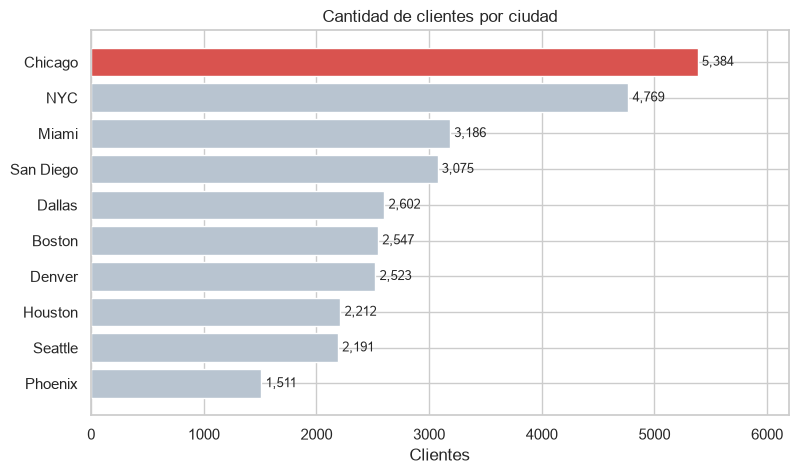

In [54]:
clientes_por_ciudad = df_restaurantes_trans_todas["ciudad_residencia"].value_counts().sort_values()

plt.figure(figsize=(9, 5))
barras = plt.barh(clientes_por_ciudad.index, clientes_por_ciudad.values, color=colores_destacando(clientes_por_ciudad.index))
plt.bar_label(barras, fmt="{:,.0f}", padding=3, fontsize=9)
plt.title("Cantidad de clientes por ciudad")
plt.xlabel("Clientes")
plt.xlim(0, clientes_por_ciudad.max() * 1.15)
plt.show()

**Interpretación:** la base está concentrada en dos ciudades: **Chicago (5.384, 18 %) y NYC (4.769, 16 %)** reúnen un tercio de los clientes. En el otro extremo, Phoenix tiene 1.511 (5 %). Esto confirma la elección de Chicago en el Avance 1: es el mercado más grande de InsightReach, y cualquier mejora en su segmentación alcanza a más clientes.

### P2. ¿Cómo se distribuyen las personas en los estratos socioeconómicos?

Un **listado** con cantidad y porcentaje, y luego la misma distribución dentro de cada ciudad para ver si todas tienen un perfil parecido.

In [55]:
tabla_frecuencias(df_restaurantes_trans_todas, "estrato_socioeconomico", orden=ORDEN_ESTRATO)

,cantidad,porcentaje
estrato_socioeconomico,,
Bajo,6161,20.54
Medio,9325,31.08
Alto,9038,30.13
Muy Alto,5476,18.25


In [56]:
estrato_por_ciudad = tabla_cruzada(df_restaurantes_trans_todas, "ciudad_residencia", "estrato_socioeconomico")
estrato_por_ciudad["Alto + Muy Alto"] = estrato_por_ciudad["Alto"] + estrato_por_ciudad["Muy Alto"]
estrato_por_ciudad.sort_values("Alto + Muy Alto", ascending=False)

estrato_socioeconomico,Bajo,Medio,Alto,Muy Alto,Alto + Muy Alto
ciudad_residencia,,,,,
Miami,14.00,24.60,36.40,25.10,61.50
San Diego,15.10,26.70,35.50,22.70,58.20
Seattle,18.50,28.00,33.10,20.40,53.50
Boston,20.70,28.60,29.80,20.90,50.70
Denver,20.00,30.30,33.60,16.10,49.70
Phoenix,22.60,31.90,28.70,16.80,45.50
Chicago,21.30,33.40,28.10,17.20,45.30
Dallas,24.00,33.20,28.30,14.50,42.80
NYC,23.80,36.00,25.50,14.80,40.30


**Interpretación:** en el total, el estrato **Medio (31 %) y el Alto (30 %)** son los más grandes; Bajo y Muy Alto rondan el 20 % cada uno. Pero las ciudades no son iguales: **Miami (61 %) y San Diego (58 %)** tienen mayoría de clientes Alto y Muy Alto, mientras que en **NYC, Houston, Dallas, Chicago y Phoenix** son menos del 46 %. Como el estrato determina el gasto (Avance 1), esta diferencia de composición explica buena parte de las diferencias entre ciudades que aparecen en las preguntas siguientes.

### P3. ¿En qué ciudades se gasta más en restaurantes al mes?

Se grafica el **gasto mensual promedio** por ciudad. También se calcula la **mediana**, porque el gasto está sesgado: pocos clientes de estrato Muy Alto gastan mucho y levantan el promedio.

In [57]:
gasto_por_ciudad = df_restaurantes_trans_todas.groupby("ciudad_residencia").agg(
    gasto_mensual_medio=("gasto_mensual", "mean"),
    gasto_mensual_mediana=("gasto_mensual", "median"),
    gasto_por_comida=("promedio_gasto_comida", "mean"),
    visitas_por_mes=("frecuencia_visita", "mean"),
).sort_values("gasto_mensual_medio", ascending=False).round(2)
gasto_por_ciudad

,gasto_mensual_medio,gasto_mensual_mediana,gasto_por_comida,visitas_por_mes
ciudad_residencia,,,,
Miami,227.01,148.20,39.82,4.78
San Diego,199.01,119.80,34.77,4.69
Phoenix,197.14,118.17,36.57,4.18
Seattle,195.19,134.05,36.85,4.41
NYC,190.32,111.76,37.10,3.99
Denver,181.88,107.61,34.28,4.22
Boston,164.14,92.10,29.50,4.35
Dallas,151.29,80.54,28.73,4.00
Chicago,139.29,75.36,25.53,4.21


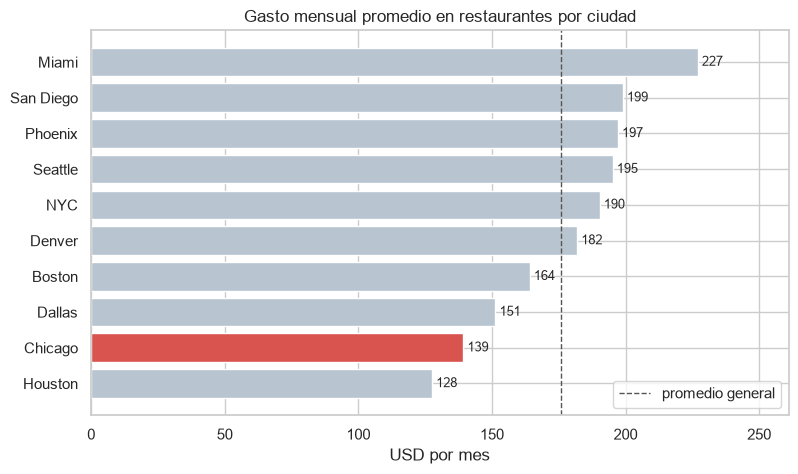

In [58]:
gasto_mensual_ordenado = gasto_por_ciudad["gasto_mensual_medio"].sort_values()
promedio_general = df_restaurantes_trans_todas["gasto_mensual"].mean()

plt.figure(figsize=(9, 5))
barras = plt.barh(gasto_mensual_ordenado.index, gasto_mensual_ordenado.values,
                  color=colores_destacando(gasto_mensual_ordenado.index))
plt.bar_label(barras, fmt="{:.0f}", padding=3, fontsize=9)
plt.axvline(promedio_general, color=COLOR_LINEA_REF, linestyle="--", linewidth=1, label="promedio general")
plt.title("Gasto mensual promedio en restaurantes por ciudad")
plt.xlabel("USD por mes")
plt.xlim(0, gasto_mensual_ordenado.max() * 1.15)
plt.legend(loc="lower right")
plt.show()

**¿Por qué varía entre ciudades?** Hay dos componentes posibles: *cuántas veces* se visita y *cuánto* se gasta por visita. Se comparan dentro de cada estrato para aislar el efecto de la composición de la ciudad.

In [59]:
pd.concat({
    "visitas por mes": df_restaurantes_trans_todas.pivot_table(index="ciudad_residencia", columns="estrato_socioeconomico",
                                            values="frecuencia_visita", aggfunc="mean", observed=True),
    "gasto por comida (USD)": df_restaurantes_trans_todas.pivot_table(index="ciudad_residencia", columns="estrato_socioeconomico",
                                                   values="promedio_gasto_comida", aggfunc="mean", observed=True),
}, axis=1).round(1)

visitas por mes                      \
estrato_socioeconomico            Bajo Medio Alto Muy Alto   
ciudad_residencia                                            
Boston                            1.50  3.40 5.00     7.50   
Chicago                           1.50  3.60 5.00     7.40   
Dallas                            1.50  3.40 5.00     7.40   
Denver                            1.60  3.40 5.00     7.50   
Houston                           1.40  3.40 5.00     7.50   
Miami                             1.60  3.50 5.00     7.50   
NYC                               1.40  3.50 5.00     7.40   
Phoenix                           1.50  3.50 5.00     7.60   
San Diego                         1.50  3.60 5.00     7.60   
Seattle                           1.60  3.40 5.00     7.40   

                       gasto por comida (USD)                       
estrato_socioeconomico                   Bajo Medio  Alto Muy Alto  
ciudad_residencia                                                   
Boston                                   7.30 20.20 34.70    56.80  
Chicago                                  5.80 17.50 32.60    54.20  
Dallas                                   7.80 22.70 32.00    70.80  
Denver                                   7.50 26.00 41.40    68.30  
Houston                                  9.10 25.70 28.80    51.10  
Miami                                   13.30 24.90 40.10    68.80  
NYC                                     11.30 30.10 45.70    80.70  
Phoenix                                  9.90 27.50 45.30    74.50  
San Diego                                9.40 22.30 37.60    61.90  
Seattle                                  9.50 29.80 43.80    60.10

**Interpretación:**
- **Miami lidera con 227 USD por mes**, seguida por San Diego, Phoenix y Seattle (cerca de 200 USD). **Houston (128 USD) y Chicago (139 USD)** están al final del ranking.
- La **frecuencia de visita es prácticamente igual en todas las ciudades** para un mismo estrato. Lo que cambia es el **gasto por comida** (el *ticket*) y la proporción de clientes de estratos altos.
- **Chicago tiene el ticket más bajo en los estratos Bajo y Medio**, y de los más bajos en Alto y Muy Alto. Sus clientes van a restaurantes tan seguido como en el resto del país, pero gastan menos en cada visita.

**Implicancia para marketing:** en Chicago la palanca no es "que vayan más veces" sino **aumentar el ticket por visita** (menús completos, maridajes, experiencias).

### P4. ¿Qué relación hay entre la frecuencia de visita y el gasto por comida, según el estrato?

Se usa un **gráfico de dispersión** coloreado por estrato. Como la frecuencia toma valores enteros (0 a 10), se le agrega un pequeño desplazamiento aleatorio (*jitter*) para que los puntos no queden apilados unos sobre otros. Para cuantificar la relación se calcula la **correlación de Pearson**, global y dentro de cada estrato.

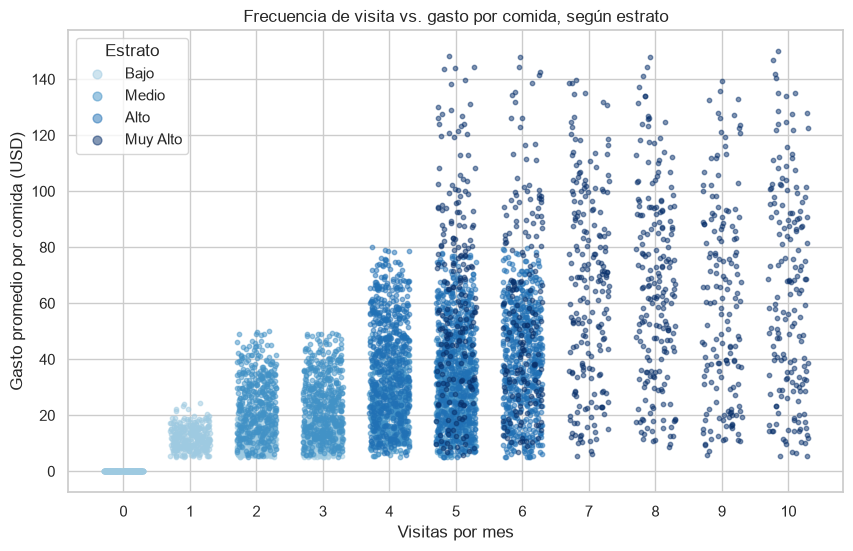

In [60]:
muestra = df_restaurantes_trans_todas.sample(6000, random_state=42)   # muestra para que el gráfico sea legible
np.random.seed(42)

plt.figure(figsize=(10, 6))
for estrato in ORDEN_ESTRATO:
    datos = muestra[muestra["estrato_socioeconomico"] == estrato]
    desplazamiento = np.random.uniform(-0.3, 0.3, len(datos))   # separa los puntos que caen en el mismo entero
    plt.scatter(datos["frecuencia_visita"] + desplazamiento, datos["promedio_gasto_comida"],
                s=10, alpha=0.5, color=PALETA_ESTRATO[estrato], label=estrato)
plt.title("Frecuencia de visita vs. gasto por comida, según estrato")
plt.xlabel("Visitas por mes")
plt.ylabel("Gasto promedio por comida (USD)")
plt.xticks(range(0, 11))
plt.legend(title="Estrato", markerscale=2)
plt.show()

In [61]:
print("Correlación frecuencia de visita – gasto por comida")
for estrato in ORDEN_ESTRATO:
    datos = df_restaurantes_trans_todas[df_restaurantes_trans_todas["estrato_socioeconomico"] == estrato]
    print(f"  {estrato:9s}: {datos['frecuencia_visita'].corr(datos['promedio_gasto_comida']):.3f}")
print(f"  TOTAL    : {df_restaurantes_trans_todas['frecuencia_visita'].corr(df_restaurantes_trans_todas['promedio_gasto_comida']):.3f}")

Correlación frecuencia de visita – gasto por comida
  Bajo     : 0.624
  Medio    : 0.009
  Alto     : 0.005
  Muy Alto : 0.015
  TOTAL    : 0.610


**Interpretación:** este es uno de los hallazgos más importantes del análisis.
- Mirando a todos los clientes juntos, la correlación es **0,61**: parece que quien va más seguido también gasta más por comida.
- Pero **dentro de cada estrato la correlación es prácticamente 0**. El gráfico muestra por qué: cada estrato forma un "bloque" separado, con su propio rango de visitas y de gasto (el Bajo va de 0 a 3 visitas y gasta menos de 25 USD; el Muy Alto va de 5 a 10 visitas y gasta hasta 150 USD). La única excepción es el estrato Bajo (0,62), por un efecto mecánico: quien no visita tiene gasto 0.
- La relación global es **aparente**: la produce una tercera variable, el **estrato**, que determina *a la vez* la frecuencia y el gasto. Es un ejemplo clásico de que **correlación no implica causalidad**.

**Implicancia para marketing:** una campaña que solo aumente la frecuencia de visita de un cliente no va a subir su gasto por comida. Frecuencia y ticket se trabajan con acciones distintas, y el estrato es la variable que define a quién dirigir cada una.

### P5. ¿Qué relación hay entre el gasto mensual en restaurantes y los ingresos mensuales?

**Gráfico de dispersión** con las 30.000 personas. Se calculan dos correlaciones: **Pearson** (relación lineal) y **Spearman** (relación monótona, basada en rankings, menos sensible a valores extremos).

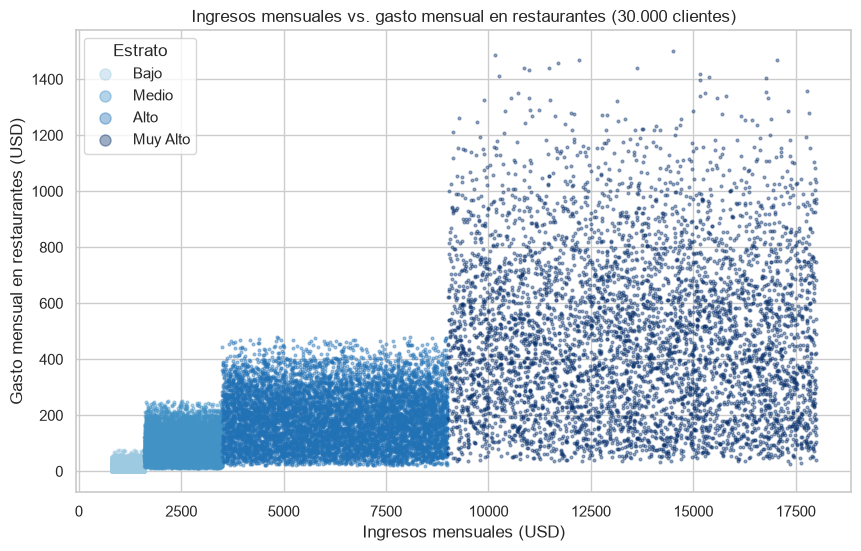

Correlación de Pearson:   0.712
Correlación de Spearman:  0.807


In [62]:
plt.figure(figsize=(10, 6))
for estrato in ORDEN_ESTRATO:
    datos = df_restaurantes_trans_todas[df_restaurantes_trans_todas["estrato_socioeconomico"] == estrato]
    plt.scatter(datos["ingresos_mensuales"], datos["gasto_mensual"], s=4, alpha=0.4,
                color=PALETA_ESTRATO[estrato], label=estrato)
plt.title("Ingresos mensuales vs. gasto mensual en restaurantes (30.000 clientes)")
plt.xlabel("Ingresos mensuales (USD)")
plt.ylabel("Gasto mensual en restaurantes (USD)")
plt.legend(title="Estrato", markerscale=4)
plt.show()

print("Correlación de Pearson:  ", round(df_restaurantes_trans_todas["ingresos_mensuales"].corr(df_restaurantes_trans_todas["gasto_mensual"]), 3))
print("Correlación de Spearman: ", round(df_restaurantes_trans_todas["ingresos_mensuales"].corr(df_restaurantes_trans_todas["gasto_mensual"], method="spearman"), 3))

In [63]:
print("Correlación ingresos – gasto mensual, dentro de cada estrato")
for estrato in ORDEN_ESTRATO:
    datos = df_restaurantes_trans_todas[df_restaurantes_trans_todas["estrato_socioeconomico"] == estrato]
    print(f"  {estrato:9s}: {datos['ingresos_mensuales'].corr(datos['gasto_mensual']):.3f}")

df_restaurantes_trans_todas["porc_ingreso_restaurantes"] = df_restaurantes_trans_todas["gasto_mensual"] / df_restaurantes_trans_todas["ingresos_mensuales"] * 100

df_restaurantes_trans_todas.groupby("estrato_socioeconomico", observed=True).agg(
    ingreso_medio=("ingresos_mensuales", "mean"),
    gasto_mensual_medio=("gasto_mensual", "mean"),
    porc_ingreso_restaurantes=("porc_ingreso_restaurantes", "median"),
).round(2)

Correlación ingresos – gasto mensual, dentro de cada estrato
  Bajo     : 0.003
  Medio    : -0.002
  Alto     : -0.002
  Muy Alto : -0.022


,ingreso_medio,gasto_mensual_medio,porc_ingreso_restaurantes
estrato_socioeconomico,,,
Bajo,1197.81,17.56,1.31
Medio,2544.76,84.94,3.01
Alto,6232.17,191.09,2.94
Muy Alto,13560.40,482.81,3.37


**Interpretación:**
- Hay una **relación positiva fuerte** entre ingresos y gasto (Pearson 0,71; Spearman 0,81): a más ingreso, más gasto en restaurantes.
- Pero se repite el patrón de P4: **dentro de cada estrato la correlación es cero**. Una persona que gana 15.000 USD no gasta más que otra del mismo estrato que gana 10.000 USD. El gasto se explica por el **estrato** (el grupo al que pertenece la persona), no por su ingreso exacto.
- En proporción, los clientes destinan **alrededor del 3 % de su ingreso** (entre 2,9 % y 3,4 %) a restaurantes en los estratos Medio, Alto y Muy Alto, y solo el 1,3 % en el Bajo.

**Implicancia para marketing:** para segmentar alcanza con el **estrato**; no hace falta conocer el ingreso exacto de cada cliente, un dato sensible y difícil de obtener.

### P6. ¿Cómo se distribuyen las preferencias alimenticias en todas las ciudades?

Un **mapa de calor** (*heatmap*) muestra el porcentaje de cada preferencia dentro de cada ciudad: cuanto más oscuro, mayor proporción. Es la forma más clara de comparar dos variables categóricas con muchas combinaciones (10 ciudades × 7 preferencias).

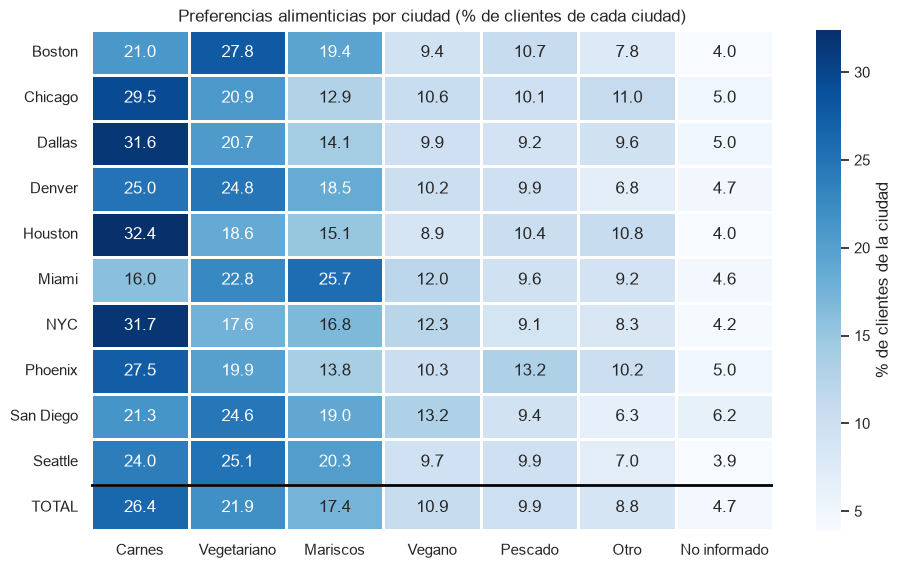

In [64]:
orden_preferencias = df_restaurantes_trans_todas["preferencias_alimenticias"].value_counts().index
preferencias_por_ciudad = tabla_cruzada(df_restaurantes_trans_todas, "ciudad_residencia", "preferencias_alimenticias")[orden_preferencias]
preferencias_por_ciudad.loc["TOTAL"] = df_restaurantes_trans_todas["preferencias_alimenticias"].value_counts(normalize=True)[orden_preferencias] * 100

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.heatmap(preferencias_por_ciudad, annot=True, fmt=".1f", cmap="Blues", linewidths=1, linecolor="white",
            cbar_kws={"label": "% de clientes de la ciudad"}, ax=ax)
ax.axhline(len(preferencias_por_ciudad) - 1, color="black", linewidth=2)
ax.set_title("Preferencias alimenticias por ciudad (% de clientes de cada ciudad)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.show()

**Interpretación:**
- En el total, **Carnes (26 %) y Vegetariano (22 %)** son las preferencias principales, seguidas de Mariscos (17 %). **Vegetarianos y veganos suman el 33 %**: un tercio de los clientes no elige carne ni pescado.
- Algunas celdas se destacan: **Miami es la ciudad de los mariscos** (26 %, su preferencia principal); **Boston, Seattle, Denver y San Diego** tienen más vegetarianos (25 % a 28 %); **Houston, NYC, Dallas y Chicago** son las más carnívoras (30 % a 32 %).
- Pero al recorrer cada columna de arriba a abajo, **los tonos son bastante parecidos**: la mezcla de preferencias es similar en todas las ciudades.

**Implicancia para marketing:** el mensaje de las campañas puede adaptarse a cada ciudad (mariscos en Miami, *plant-based* en Boston y Seattle), pero las diferencias son moderadas: en todas las ciudades hay público para todos los tipos de comida.

### P7. ¿Cómo son los clientes de mayor gasto?

Se define como **clientes de mayor gasto al 10 % que más gasta por mes** (percentil 90). Para describirlos se los compara con el resto: una característica solo es distintiva si aparece en ellos con una frecuencia distinta que en los demás.

In [65]:
umbral_top = df_restaurantes_trans_todas["gasto_mensual"].quantile(0.90)
df_restaurantes_trans_todas["segmento_gasto"] = np.where(df_restaurantes_trans_todas["gasto_mensual"] >= umbral_top, "Top 10 %", "Resto")

print(f"Umbral del top 10 %: {umbral_top:.0f} USD por mes | "
      f"Clientes: {(df_restaurantes_trans_todas['segmento_gasto'] == 'Top 10 %').sum():,}")

df_restaurantes_trans_todas.groupby("segmento_gasto").agg(
    clientes=("id_persona", "count"),
    gasto_mensual_medio=("gasto_mensual", "mean"),
    gasto_mensual_mediana=("gasto_mensual", "median"),
    gasto_por_comida=("promedio_gasto_comida", "mean"),
    visitas_por_mes=("frecuencia_visita", "mean"),
    ingreso_medio=("ingresos_mensuales", "mean"),
    edad_media=("edad", "mean"),
).round(1)

Umbral del top 10 %: 424 USD por mes | Clientes: 3,000


,clientes,gasto_mensual_medio,gasto_mensual_mediana,gasto_por_comida,visitas_por_mes,ingreso_medio,edad_media
segmento_gasto,,,,,,,
Resto,27000,118.30,87.00,26.30,3.90,4518.00,49.00
Top 10 %,3000,692.70,646.10,89.60,7.80,13235.20,48.50


In [66]:
tabla_cruzada(df_restaurantes_trans_todas, "segmento_gasto", "estrato_socioeconomico")

estrato_socioeconomico,Bajo,Medio,Alto,Muy Alto
segmento_gasto,,,,
Resto,22.80,34.50,33.00,9.60
Top 10 %,0.00,0.00,3.80,96.20


In [67]:
tabla_cruzada(df_restaurantes_trans_todas, "segmento_gasto", "membresia_premium")

membresia_premium,No,Sí
segmento_gasto,,
Resto,62.90,37.10
Top 10 %,5.30,94.70


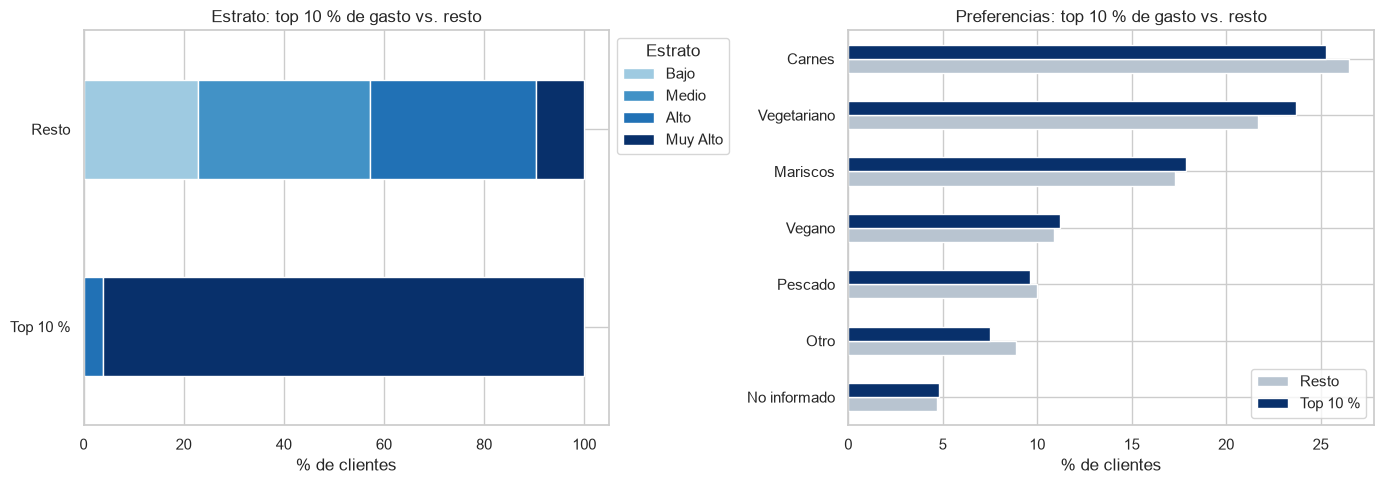

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

perfil_estrato = tabla_cruzada(df_restaurantes_trans_todas, "segmento_gasto", "estrato_socioeconomico")[ORDEN_ESTRATO].loc[["Top 10 %", "Resto"]]
perfil_estrato.plot(kind="barh", stacked=True, color=list(PALETA_ESTRATO.values()), edgecolor="white", ax=axes[0])
axes[0].set_title("Estrato: top 10 % de gasto vs. resto")
axes[0].set_xlabel("% de clientes")
axes[0].set_ylabel("")
axes[0].legend(title="Estrato", bbox_to_anchor=(1, 1))

perfil_preferencias = tabla_cruzada(df_restaurantes_trans_todas, "segmento_gasto", "preferencias_alimenticias").T.sort_values("Top 10 %")
perfil_preferencias[["Resto", "Top 10 %"]].plot(kind="barh", color=[COLOR_BASE, COLOR_PRINCIPAL], ax=axes[1])
axes[1].set_title("Preferencias: top 10 % de gasto vs. resto")
axes[1].legend(title="")
axes[1].set_xlabel("% de clientes")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

**Interpretación:** el cliente de mayor gasto **gasta más de 424 USD por mes** (693 USD en promedio, seis veces más que el resto). Su perfil:
- **96 % pertenece al estrato Muy Alto** y **95 % tiene membresía premium** (contra 37 % del resto).
- Va a restaurantes **casi 8 veces por mes** y gasta unos **90 USD por comida**.
- **Qué le gusta comer:** lo mismo que al resto. Carnes (25 %), vegetariano (24 %) y mariscos (18 %), con diferencias de uno o dos puntos. **La preferencia alimenticia no distingue al cliente de alto gasto; el estrato sí.**
- Tampoco lo distingue la edad: 48 años en promedio, igual que el resto.

**Implicancia para marketing:** el cliente de alto valor se identifica por su estrato y su membresía premium. Dentro de ese grupo, la preferencia alimenticia sirve para **personalizar el mensaje** (qué restaurante ofrecerle), no para encontrarlo.

### P8. ¿En qué ciudad se pagan más membresías premium?

La pregunta admite dos lecturas que llevan a respuestas distintas, así que se muestran las dos en **gráficos separados** (no en un mismo gráfico con dos escalas, que confunde la lectura):
- **Cantidad** de membresías: dónde hay más miembros.
- **Tasa** de membresía: qué porcentaje de los clientes de cada ciudad es miembro.

In [69]:
membresia_por_ciudad = df_restaurantes_trans_todas.groupby("ciudad_residencia").agg(
    miembros=("membresia_premium", lambda s: (s == "Sí").sum()),
    porc_membresia=("membresia_premium", porcentaje_si),
).round(1)
membresia_por_ciudad.sort_values("miembros", ascending=False)

,miembros,porc_membresia
ciudad_residencia,,
Chicago,2215,41.10
NYC,1775,37.20
Miami,1694,53.20
San Diego,1502,48.80
Boston,1139,44.70
Denver,1068,42.30
Seattle,1023,46.70
Dallas,992,38.10
Houston,808,36.50


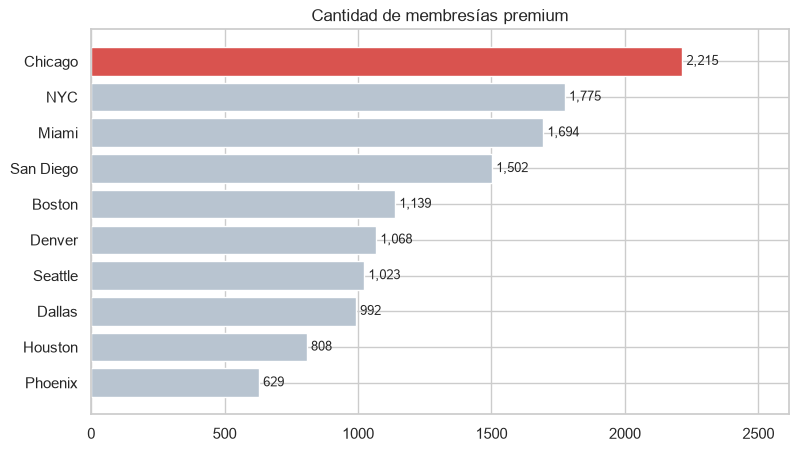

In [70]:
miembros_ordenado = membresia_por_ciudad["miembros"].sort_values()

plt.figure(figsize=(9, 5))
barras = plt.barh(miembros_ordenado.index, miembros_ordenado.values, color=colores_destacando(miembros_ordenado.index))
plt.bar_label(barras, fmt="{:,.0f}", padding=3, fontsize=9)
plt.title("Cantidad de membresías premium")
plt.xlim(0, miembros_ordenado.max() * 1.18)
plt.show()

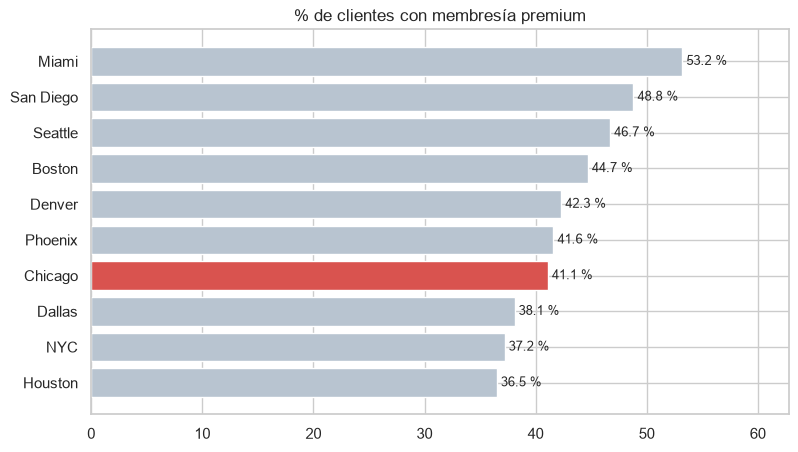

In [71]:
porc_membresia_ordenado = membresia_por_ciudad["porc_membresia"].sort_values()

plt.figure(figsize=(9, 5))
barras = plt.barh(porc_membresia_ordenado.index, porc_membresia_ordenado.values, color=colores_destacando(porc_membresia_ordenado.index))
plt.bar_label(barras, fmt="{:.1f} %", padding=3, fontsize=9)
plt.title("% de clientes con membresía premium")
plt.xlim(0, porc_membresia_ordenado.max() * 1.18)
plt.show()

In [72]:
# % de membresía dentro de cada estrato, por ciudad
df_restaurantes_trans_todas.pivot_table(index="ciudad_residencia", columns="estrato_socioeconomico", values="membresia_premium",
                 aggfunc=porcentaje_si, observed=True).round(0)

estrato_socioeconomico,Bajo,Medio,Alto,Muy Alto
ciudad_residencia,,,,
Boston,0.00,15.00,69.00,95.00
Chicago,1.00,13.00,72.00,95.00
Dallas,0.00,13.00,70.00,96.00
Denver,0.00,13.00,70.00,93.00
Houston,0.00,15.00,68.00,96.00
Miami,0.00,15.00,70.00,96.00
NYC,1.00,16.00,67.00,96.00
Phoenix,0.00,16.00,71.00,96.00
San Diego,0.00,12.00,68.00,95.00


**Interpretación:**
- **En cantidad, Chicago es la ciudad con más membresías premium (2.215)**, simplemente porque es la ciudad con más clientes.
- **En proporción, Miami lidera: el 53 % de sus clientes es premium**, seguida por San Diego (49 %). Chicago está en la mitad de la tabla (41 %).
- La tasa de membresía de una ciudad se explica casi por completo por **cuántos clientes de estrato alto tiene**. Dentro de cada estrato la tasa es la misma en todas las ciudades: alrededor del 0 % en el Bajo, 14 % en el Medio, 70 % en el Alto y 95 % en el Muy Alto.

**Implicancia para marketing:** no hay ciudades "más propensas" a la membresía, hay ciudades con más clientes de estrato alto. La oportunidad de crecimiento está en el **estrato Medio**, donde la adhesión es baja (14 %) en todas partes.

### P9. ¿Qué relación hay entre el consumo de alcohol en restaurantes y la edad?

Se calcula el **porcentaje de consumidores para cada edad exacta** (gráfico de línea, que muestra cómo evoluciona una proporción a lo largo de una variable ordenada). Luego se resume por tramos de edad y se compara con el estrato, para ver cuál de las dos variables importa.

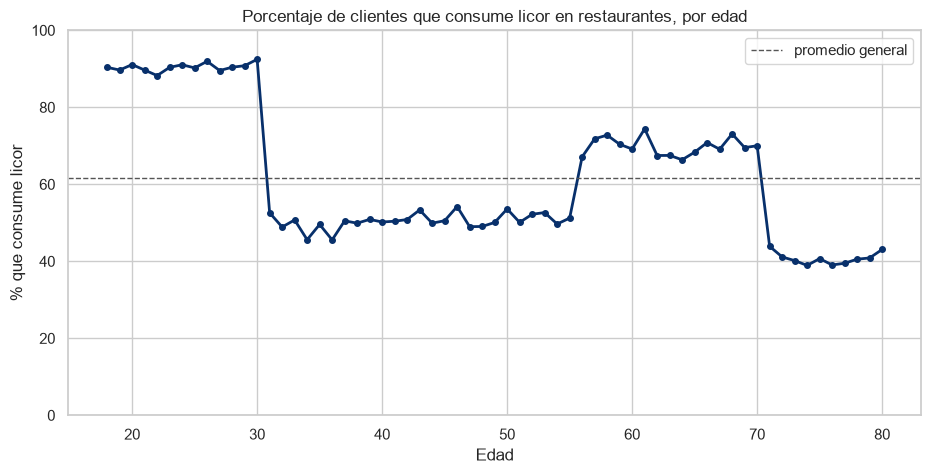

In [73]:
licor_por_edad = df_restaurantes_trans_todas.groupby("edad")["consume_licor"].agg(porcentaje_si)

plt.figure(figsize=(11, 5))
plt.plot(licor_por_edad.index, licor_por_edad.values, color=COLOR_PRINCIPAL, linewidth=2, marker="o", markersize=4)
plt.axhline(porcentaje_si(df_restaurantes_trans_todas["consume_licor"]), color=COLOR_LINEA_REF, linestyle="--", linewidth=1,
            label="promedio general")
plt.title("Porcentaje de clientes que consume licor en restaurantes, por edad")
plt.xlabel("Edad")
plt.ylabel("% que consume licor")
plt.ylim(0, 100)
plt.legend()
plt.show()

In [74]:
# Tramos definidos a partir de los escalones que muestra el gráfico
tramo_edad = pd.cut(df_restaurantes_trans_todas["edad"], bins=[17, 30, 55, 70, 80], labels=["18-30", "31-55", "56-70", "71-80"]).rename("tramo_edad")
(pd.crosstab(tramo_edad, df_restaurantes_trans_todas["consume_licor"], normalize="index") * 100).round(1)

consume_licor,No,Sí
tramo_edad,,
18-30,9.60,90.40
31-55,49.60,50.40
56-70,30.10,69.90
71-80,59.20,40.80


In [75]:
tabla_cruzada(df_restaurantes_trans_todas, "estrato_socioeconomico", "consume_licor")

consume_licor,No,Sí
estrato_socioeconomico,,
Bajo,38.30,61.70
Medio,38.50,61.50
Alto,38.50,61.50
Muy Alto,38.20,61.80


**Interpretación:**
- La relación **no es lineal ni gradual: va por escalones**. Entre los **18 y 30 años consume el 90 %**; de **31 a 55 baja al 50 %**; de **56 a 70 sube al 70 %**; y **desde los 71 cae al 40 %**.
- En cambio, **el estrato no influye**: consume entre el 61,5 % y el 61,8 % de los clientes en todos los niveles socioeconómicos (última tabla).
- **Observación sobre los datos:** los cambios son abruptos en edades exactas (de 90 % a los 30 años a 53 % a los 31). En comportamientos reales las transiciones suelen ser más graduales, lo que sugiere que la base pudo haberse generado con reglas por tramos. En un proyecto real convendría validar este patrón con otra fuente antes de invertir en él.

**Implicancia para marketing:** las promociones de bebidas deben apuntar a **edad, no a estrato**. Los jóvenes de 18 a 30 años son el público natural (9 de cada 10 consumen), y el grupo de 56 a 70 es un segundo público relevante.

## 13. Análisis integrado de Chicago: clientes + oferta de Yelp

Se carga la base enriquecida del **Avance 2** con el mismo nombre que tiene allí, `df_clientes_enriquecido`: cada cliente de Chicago tiene asociada la oferta de Yelp que corresponde a su preferencia y su nivel de precio (`estado_oferta`, `restaurantes_afines`, `restaurante_sugerido`).

In [76]:
df_clientes_enriquecido = pd.read_csv(RUTA_ENRIQUECIDO, dtype={"id_persona": str})
df_clientes_enriquecido["estrato_socioeconomico"] = pd.Categorical(df_clientes_enriquecido["estrato_socioeconomico"],
                                                            categories=ORDEN_ESTRATO, ordered=True)
df_clientes_enriquecido["gasto_mensual"] = df_clientes_enriquecido["promedio_gasto_comida"] * df_clientes_enriquecido["frecuencia_visita"]
df_clientes_enriquecido["contactable"] = ((df_clientes_enriquecido["telefono_contacto"] != "Dato no cargado")
                                  | (df_clientes_enriquecido["correo_electronico"] != "Dato no cargado"))

assert len(df_clientes_enriquecido) == len(df_restaurantes_trans), "La base enriquecida no coincide con los clientes de Chicago"
print(f"Clientes: {len(df_clientes_enriquecido):,}")
df_clientes_enriquecido["estado_oferta"].value_counts()

Clientes: 5,384


estado_oferta
Con oferta afín                     4474
Sin oferta en su rango de precio     392
No consume en restaurantes           261
Preferencia no informada             257
Name: count, dtype: int64

### 13.1 ¿Dónde está el valor? Clientes vs. gasto por estrato

Para decidir dónde invertir en marketing no alcanza con saber cuántos clientes hay en cada grupo: importa **cuánto gasto concentran**.

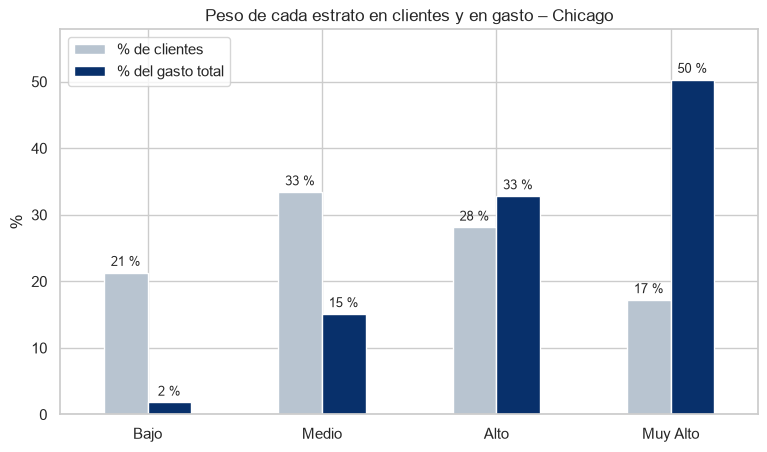

,porc_clientes,porc_gasto_total
estrato_socioeconomico,,
Bajo,21.30,1.80
Medio,33.40,15.10
Alto,28.10,32.80
Muy Alto,17.20,50.30


In [77]:
valor_por_estrato = pd.DataFrame({
    "porc_clientes": df_clientes_enriquecido["estrato_socioeconomico"].value_counts(normalize=True) * 100,
    "porc_gasto_total": df_clientes_enriquecido.groupby("estrato_socioeconomico", observed=True)["gasto_mensual"].sum()
                        / df_clientes_enriquecido["gasto_mensual"].sum() * 100,
}).reindex(ORDEN_ESTRATO).round(1)

ax = valor_por_estrato.plot(kind="bar", color=[COLOR_BASE, COLOR_PRINCIPAL], figsize=(9, 5), rot=0)
for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%.0f %%", padding=3, fontsize=9)
ax.legend(["% de clientes", "% del gasto total"])
ax.set_title(f"Peso de cada estrato en clientes y en gasto – {CIUDAD}")
ax.set_ylabel("%")
ax.set_xlabel("")
ax.set_ylim(0, valor_por_estrato.values.max() * 1.15)
plt.show()
valor_por_estrato

**Interpretación:** el estrato **Muy Alto es el 17 % de los clientes pero genera el 50 % del gasto** en restaurantes de Chicago. Junto con el Alto, el 45 % de los clientes concentra el 83 % del gasto. En el otro extremo, el estrato Bajo es el 21 % de los clientes y apenas el 2 % del gasto.

### 13.2 ¿A cuántos clientes se puede contactar?

In [78]:
pd.Series({
    "Con teléfono": (df_clientes_enriquecido["telefono_contacto"] != "Dato no cargado").mean() * 100,
    "Con correo": (df_clientes_enriquecido["correo_electronico"] != "Dato no cargado").mean() * 100,
    "Con al menos un canal": df_clientes_enriquecido["contactable"].mean() * 100,
    "Sin ningún canal": (~df_clientes_enriquecido["contactable"]).mean() * 100,
}).round(1).to_frame("porc_clientes")

,porc_clientes
Con teléfono,49.30
Con correo,49.60
Con al menos un canal,74.80
Sin ningún canal,25.20


**Interpretación:** cada canal por separado está disponible solo para la mitad de los clientes, pero **combinando teléfono y correo se llega al 75 %**. Las campañas deben usar **ambos canales**; el 25 % restante solo se alcanza por medios masivos (redes, la app o el propio restaurante).

## 14. Segmentación y recomendaciones

### 14.1 Definición de segmentos

A partir de los hallazgos anteriores se definen **cinco segmentos accionables** en Chicago. No son excluyentes: un cliente puede pertenecer a más de uno (por ejemplo, un joven de estrato Muy Alto). Cada segmento responde a un hallazgo concreto:

| Segmento | Criterio | Hallazgo que lo origina |
|---|---|---|
| **A. Plant-based premium sin oferta** | Vegetarianos y veganos sin restaurantes en su rango de precio | Avance 2: no hay oferta vegana de nivel $$$ o $$$$ |
| **B. Alto valor** | Estrato Muy Alto | 13.1 y P7: 17 % de los clientes, 50 % del gasto |
| **C. Medio sin membresía** | Estrato Medio sin membresía premium | P8: la adhesión premium es baja en el estrato Medio |
| **D. Jóvenes 18–30** | Edad entre 18 y 30 años | P9: 90 % consume licor |
| **E. Bajo presupuesto** | Estrato Bajo que visita restaurantes | Avance 2: el nivel $ tiene poca oferta (28 % de clientes vs. 11 % de restaurantes) |

In [79]:
SEGMENTOS = {
    "A. Plant-based premium sin oferta": df_clientes_enriquecido["estado_oferta"] == "Sin oferta en su rango de precio",
    "B. Alto valor (Muy Alto)": df_clientes_enriquecido["estrato_socioeconomico"] == "Muy Alto",
    "C. Medio sin membresía": (df_clientes_enriquecido["estrato_socioeconomico"] == "Medio") & (df_clientes_enriquecido["membresia_premium"] == "No"),
    "D. Jóvenes 18-30": df_clientes_enriquecido["edad"] <= 30,
    "E. Bajo presupuesto": (df_clientes_enriquecido["estrato_socioeconomico"] == "Bajo") & (df_clientes_enriquecido["frecuencia_visita"] > 0),
}


def resumir_segmento(df, mascara):
    """Indicadores clave de un segmento de clientes."""
    d = df[mascara]
    return {
        "clientes": len(d),
        "porc_clientes": len(d) / len(df) * 100,
        "porc_gasto_total": d["gasto_mensual"].sum() / df["gasto_mensual"].sum() * 100,
        "gasto_mensual_medio": d["gasto_mensual"].mean(),
        "gasto_por_comida": d["promedio_gasto_comida"].mean(),
        "visitas_por_mes": d["frecuencia_visita"].mean(),
        "porc_premium": porcentaje_si(d["membresia_premium"]),
        "porc_consume_licor": porcentaje_si(d["consume_licor"]),
        "porc_contactable": d["contactable"].mean() * 100,
        "porc_oferta_afin_yelp": (d["estado_oferta"] == "Con oferta afín").mean() * 100,
    }


resumen_segmentos = pd.DataFrame(
    {nombre: resumir_segmento(df_clientes_enriquecido, mascara) for nombre, mascara in SEGMENTOS.items()}
).T.round(1)
resumen_segmentos

,clientes,porc_clientes,porc_gasto_total,gasto_mensual_medio,gasto_por_comida,visitas_por_mes,porc_premium,porc_consume_licor,porc_contactable,porc_oferta_afin_yelp
A. Plant-based premium sin oferta,392.00,7.30,15.40,294.30,49.00,5.90,81.40,60.20,75.00,0.00
B. Alto valor (Muy Alto),927.00,17.20,50.30,407.30,54.20,7.40,95.30,61.70,76.20,79.80
C. Medio sin membresía,1563.00,29.00,13.10,62.70,17.40,3.60,0.00,63.70,75.90,94.30
D. Jóvenes 18-30,1135.00,21.10,21.10,139.20,25.20,4.30,40.50,90.40,75.90,84.00
E. Bajo presupuesto,887.00,16.50,1.80,15.10,7.50,2.00,0.70,63.40,71.10,95.80


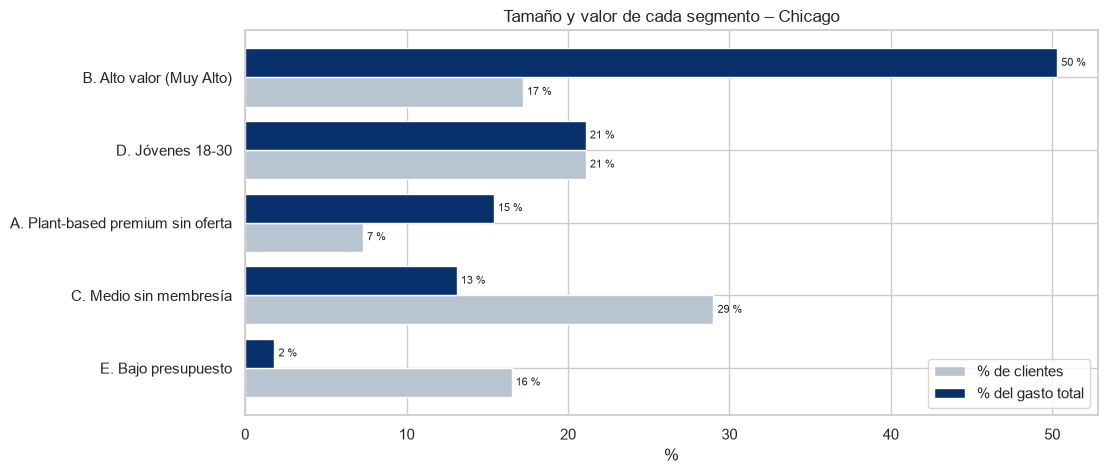

In [80]:
ax = (resumen_segmentos.sort_values("porc_gasto_total")[["porc_clientes", "porc_gasto_total"]]
      .plot(kind="barh", color=[COLOR_BASE, COLOR_PRINCIPAL], figsize=(11, 5), width=0.8))
for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%.0f %%", padding=3, fontsize=8)
ax.legend(["% de clientes", "% del gasto total"], loc="lower right")
ax.set_title(f"Tamaño y valor de cada segmento – {CIUDAD}")
ax.set_xlabel("%")
ax.set_ylabel("")
plt.show()

**Evidencia para el segmento C:** ¿los miembros premium del estrato Medio consumen más que los no miembros?

In [81]:
df_clientes_enriquecido[df_clientes_enriquecido["estrato_socioeconomico"] == "Medio"].groupby("membresia_premium").agg(
    clientes=("id_persona", "count"),
    visitas_por_mes=("frecuencia_visita", "mean"),
    gasto_por_comida=("promedio_gasto_comida", "mean"),
    gasto_mensual_medio=("gasto_mensual", "mean"),
).round(2)

,clientes,visitas_por_mes,gasto_por_comida,gasto_mensual_medio
membresia_premium,,,,
No,1563,3.59,17.43,62.69
Sí,235,3.60,17.63,64.38


En el estrato Medio, miembros y no miembros **visitan y gastan prácticamente lo mismo**. La membresía, tal como está, no cambia el comportamiento de consumo: por eso la recomendación para este segmento no es solo "vender más membresías", sino rediseñar sus beneficios para que incentiven más visitas o un ticket mayor.

### 14.2 Detalle del segmento A: la oportunidad *plant-based* premium

In [82]:
segmento_a = df_clientes_enriquecido[SEGMENTOS["A. Plant-based premium sin oferta"]]

print(f"Clientes: {len(segmento_a)} | Gasto mensual total del segmento: {segmento_a['gasto_mensual'].sum():,.0f} USD")
pd.crosstab(segmento_a["preferencias_alimenticias"], segmento_a["nivel_precio_objetivo"].map(SIMBOLO_PRECIO),
            margins=True, margins_name="Total")

Clientes: 392 | Gasto mensual total del segmento: 115,376 USD


nivel_precio_objetivo,$$$,$$$$,Total
preferencias_alimenticias,,,
Vegano,114,41,155
Vegetariano,237,0,237
Total,351,41,392


In [83]:
segmento_a["estrato_socioeconomico"].astype(str).value_counts().to_frame("clientes")

,clientes
estrato_socioeconomico,
Alto,252
Muy Alto,140


**Interpretación:** son **392 clientes (7 %) que concentran el 15 % del gasto** en restaurantes de Chicago: gastan unos **294 USD por mes**, el doble del promedio, y el 81 % ya es premium. Son vegetarianos que gastan en rango $$$ y veganos que gastan en $$$ y $$$$, de estratos Alto y Muy Alto. Según Yelp, en Chicago **no hay restaurantes veganos de esos niveles de precio**, y solo uno vegetariano $$$$. Es demanda de alto valor que hoy no tiene dónde ir.

### 14.3 Recomendaciones

| Segmento | Acción recomendada | Canal | Cómo medir el resultado |
|---|---|---|---|
| **A. Plant-based premium sin oferta** (392 clientes, 15 % del gasto) | **Ofrecer a restaurantes de alta gama (carnes, mariscos, cocina de autor) una campaña para lanzar menús de degustación vegetarianos y veganos**, y comunicarla a este segmento. Para restaurantes *plant-based* de precio medio, una línea premium (cenas especiales, maridajes). | Correo y teléfono (75 % contactable); mensajes personalizados por preferencia | Reservas del segmento en los nuevos menús; % del segmento que pasa a "con oferta afín" |
| **B. Alto valor** (17 % de clientes, 50 % del gasto) | **Fidelizar**, no captar: beneficios exclusivos para miembros premium (reservas prioritarias, eventos de chef, acceso anticipado). Personalizar el restaurante recomendado según su preferencia. La oferta de nivel $$$$ en carnes y mariscos está bien calificada en Yelp. | Correo y app, con mensajes de tono exclusivo | Tasa de retención y frecuencia de visita del segmento |
| **C. Medio sin membresía** (1.563 clientes) | Campaña de **conversión a premium** con un beneficio de entrada (primer mes sin costo, descuento en restaurantes $$). Hoy los miembros del estrato Medio gastan lo mismo que los no miembros, así que la membresía debe ofrecer **beneficios que cambien el comportamiento** (por ejemplo, descuento por segunda visita en el mes). | Correo, teléfono y app | Tasa de conversión; gasto mensual de los nuevos miembros frente a los no miembros |
| **D. Jóvenes 18-30** (21 % de clientes, 90 % consume licor) | **Promociones de bebidas** con bares y restaurantes: *happy hours*, 2x1 en cócteles, maridajes. Dirigirlas por edad, no por estrato (el estrato no influye en el consumo de licor). | Redes sociales y app | Canje de promociones; ticket promedio con bebida |
| **E. Bajo presupuesto** (887 clientes que visitan restaurantes) | Promociones de **precio fijo y menú del día** con restaurantes económicos. El nivel $ tiene poca oferta en Yelp frente a su demanda: es una oportunidad para restaurantes que quieran captar volumen. | Correo y teléfono; la app para cupones | Visitas por mes del segmento |

**Recomendaciones transversales:**
- **Aumentar el ticket, no solo la frecuencia (P3 y P4):** en Chicago los clientes visitan restaurantes tan seguido como en otras ciudades pero gastan menos por visita. Las campañas deberían proponer experiencias completas (entrada + principal + bebida).
- **Segmentar por estrato y edad, no por ingreso exacto (P5 y P9).**
- **Completar datos de contacto y preferencias:** el 25 % de los clientes no tiene ningún canal y el 5 % no informó su preferencia. Una campaña de actualización de perfil (por ejemplo, un beneficio a cambio de completar los datos) mejoraría todas las demás.

### 14.4 Calidad de los datos: una recomendación para la empresa

Todo el análisis depende de la base recibida, y esa base llegó con errores de carga **sistemáticos**: valores centinela (edades de -5 y 300 años, visitas de -3 por mes) y campos vacíos. Se cuantifica cuántos registros de la **base original** tenían algún problema:

In [84]:
edad = df_restaurantes_base["edad"]

problemas = {
    "Edad faltante o imposible": edad.isna() | (edad < EDAD_MIN) | (edad > EDAD_MAX),
    "Frecuencia de visita imposible": df_restaurantes_base["frecuencia_visita"] < 0,
    "Gasto por comida faltante": df_restaurantes_base["promedio_gasto_comida"].isna(),
    "Preferencia alimenticia faltante": df_restaurantes_base["preferencias_alimenticias"].isna(),
}
problemas["Al menos uno de los anteriores"] = pd.concat(problemas, axis=1).any(axis=1)
problemas["Sin teléfono ni correo"] = (df_restaurantes_base["telefono_contacto"].isna()
                                       & df_restaurantes_base["correo_electronico"].isna())
problemas["Algún problema, contando el contacto"] = (problemas["Al menos uno de los anteriores"]
                                                     | problemas["Sin teléfono ni correo"])

pd.DataFrame({
    "cantidad": {nombre: mascara.sum() for nombre, mascara in problemas.items()},
    "porcentaje": {nombre: mascara.mean() * 100 for nombre, mascara in problemas.items()},
}).round(1)

,cantidad,porcentaje
Edad faltante o imposible,308,1.00
Frecuencia de visita imposible,1547,5.20
Gasto por comida faltante,145,0.50
Preferencia alimenticia faltante,1403,4.70
Al menos uno de los anteriores,3280,10.90
Sin teléfono ni correo,7679,25.60
"Algún problema, contando el contacto",10105,33.70


**Interpretación:** uno de cada tres clientes (34 %) tiene algún dato faltante o erróneo. En el análisis se trataron con criterios justificados, pero **imputar no recupera la información: solo la estima**. Las conclusiones se sostienen porque las variables clave (estrato, ingresos y ciudad) estaban completas; lo que se pierde de verdad es valor comercial: un cliente de cada cuatro no puede ser contactado y uno de cada veinte no puede recibir una oferta personalizada.

**Recomendación: mayor rigurosidad en la recolección de datos.**
1. **Validar en el momento de la carga:** que el sistema no acepte edades fuera de 18 a 100 años ni visitas negativas.
2. **No usar valores centinela:** si un dato no se conoce, se deja vacío o se usa un código documentado, nunca un número que parece real.
3. **Definir campos obligatorios mínimos:** al menos un canal de contacto y la preferencia alimenticia.
4. **Crear un diccionario de datos:** qué significa cada columna, su unidad y sus valores válidos (por ejemplo, que la frecuencia de visita es mensual, algo que aquí hubo que suponer).
5. **Controlar la calidad periódicamente:** un reporte mensual con el porcentaje de nulos y errores por campo.

## 15. Conclusiones finales

**Sobre el negocio**
1. **El estrato socioeconómico es la variable que ordena todo el comportamiento de consumo:** define cuántas veces se visita, cuánto se gasta por visita y quién tiene membresía. Las relaciones aparentes entre frecuencia y gasto, o entre ingreso y gasto, desaparecen dentro de cada estrato.
2. **El valor está concentrado:** en Chicago, el 17 % de los clientes (Muy Alto) genera la mitad del gasto. El top 10 % de gasto del país es 96 % Muy Alto y 95 % premium.
3. **Las diferencias entre ciudades se explican por su composición** (cuántos clientes de estrato alto tienen) y por el ticket por visita, no por la frecuencia. Chicago es el mercado más grande pero tiene uno de los tickets más bajos: la oportunidad es aumentar el gasto por visita.
4. **La mayor oportunidad concreta es el segmento *plant-based* premium:** 392 clientes de alto gasto sin oferta acorde en Yelp.
5. **El consumo de licor depende de la edad, no del estrato:** 90 % entre los 18 y 30 años.
6. **La calidad de la base es el principal límite del análisis:** el 34 % de los registros tenía algún dato faltante o erróneo. Se recomienda a la empresa validar los datos al cargarlos (sección 14.4).

**Sobre el proceso**
- Se integraron **tres fuentes**: la base de clientes, la oferta de restaurantes de Yelp y variables construidas (gasto mensual, nivel de precio objetivo, estado de oferta).
- Se aplicaron técnicas estadísticas para respaldar cada conclusión: correlaciones de Pearson y Spearman, calculadas en el total y dentro de cada estrato, y comparaciones por segmento con tablas cruzadas.
- El código se organizó en **funciones reutilizables** (`tabla_frecuencias`, `tabla_cruzada`, `porcentaje_si`, `limpiar_base`, `resumir_segmento`) y con **nombres congruentes de principio a fin** (ver la tabla del inicio), lo que permite repetir el análisis para otra ciudad cambiando una sola variable.

**Limitaciones**
- El gasto mensual es una estimación (gasto por comida × visitas por mes).
- La oferta vegetariana y vegana de Yelp probablemente está subestimada, porque Yelp solo etiqueta así a los locales especializados.
- Algunos patrones son muy regulares (escalones exactos por edad, estratos sin superposición de ingresos), lo que sugiere datos generados por reglas. Las recomendaciones deberían validarse con una prueba piloto antes de escalarlas.